<a href="https://colab.research.google.com/github/jaronkawam/EE675_final_project/blob/main/ee675project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import pandas as pd

from scipy.io import loadmat
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
print(os.listdir())
os.chdir('./drive/My Drive/Year 4/EE 675/Project/')

['.config', 'drive', 'sample_data']


In [ ]:
# !tar -xzf handwritingBCIData.tar.gz -C ./Data

dict_keys(['__header__', '__version__', '__globals__', 'neuralActivityCube_straightLine_short_1', 'neuralActivityCube_straightLine_short_2', 'neuralActivityCube_straightLine_short_3', 'neuralActivityCube_straightLine_short_4', 'neuralActivityCube_straightLine_short_5', 'neuralActivityCube_straightLine_short_6', 'neuralActivityCube_straightLine_short_7', 'neuralActivityCube_straightLine_short_8', 'neuralActivityCube_straightLine_short_9', 'neuralActivityCube_straightLine_short_10', 'neuralActivityCube_straightLine_short_11', 'neuralActivityCube_straightLine_short_12', 'neuralActivityCube_straightLine_short_13', 'neuralActivityCube_straightLine_short_14', 'neuralActivityCube_straightLine_short_15', 'neuralActivityCube_straightLine_short_16', 'neuralActivityCube_straightLine_medium_1', 'neuralActivityCube_straightLine_medium_2', 'neuralActivityCube_straightLine_medium_3', 'neuralActivityCube_straightLine_medium_4', 'neuralActivityCube_straightLine_medium_5', 'neuralActivityCube_straightLi

(array([112.,  26.,  17.,  13.,   9.,   5.,   6.,   0.,   1.,   3.]),
 array([ 235. ,  675.7, 1116.4, 1557.1, 1997.8, 2438.5, 2879.2, 3319.9,
        3760.6, 4201.3, 4642. ]),
 <BarContainer object of 10 artists>)

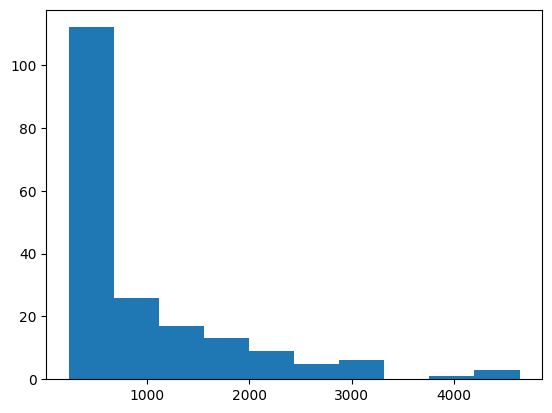

In [ ]:
# instructed delay straight-line writing (24 repetitions each for 48 straight-line conditions)
# each key has dimensions 24 x 201 x 192 --> 24 trials for 201 ten millisecond bins across two 96 Utah arrays
# binned spike counts are what is represented in the data
mat_file_path = './Data/handwritingBCIData/Datasets/t5.2019.06.03/straightLines.mat'
mat_data = loadmat(mat_file_path)

# Display the keys in the loaded .mat file to understand its structure
print(mat_data.keys())
print(np.shape(mat_data['neuralActivityCube_straightLine_short_1']))
plt.hist(mat_data['neuralActivityCube_straightLine_short_1'].sum(axis=(0,1)).flatten())

### Data Description

(359173, 192)
(359173, 1)
(359173, 1)
(8, 1)
(8, 1)
(1152, 1)
(1152, 1)
(1152, 1)
(10, 10)
[3.3997] [463.2609]
[4.8355] [447.1261]
[[  4.8355]
 [  4.8455]
 [  4.8555]
 ...
 [447.1061]
 [447.1161]
 [447.1261]]
[4] [19]


(array([44878., 45247., 45254.,     0., 44584., 45844., 44028.,     0.,
        45107., 44231.]),
 array([ 4. ,  5.5,  7. ,  8.5, 10. , 11.5, 13. , 14.5, 16. , 17.5, 19. ]),
 <BarContainer object of 10 artists>)

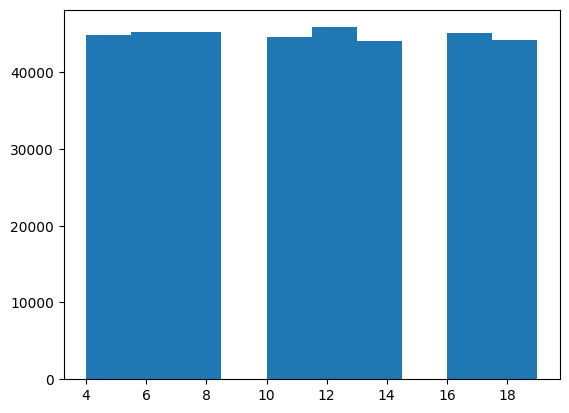

In [ ]:
# 'neuralActivityTimeSeries', 'clockTimeSeries', 'blockNumsTimeSeries', 'blockList', 'blockStartDates', 'goPeriodOnsetTimeBin', 'delayPeriodOnsetTimeBin', 'movementCues', 'arrayGeometryMap'
print(np.shape(mat_data['neuralActivityTimeSeries']))
print(np.shape(mat_data['clockTimeSeries']))
print(np.shape(mat_data['blockNumsTimeSeries']))
print(np.shape(mat_data['blockList']))
print(np.shape(mat_data['blockStartDates']))
print(np.shape(mat_data['goPeriodOnsetTimeBin']))
print(np.shape(mat_data['delayPeriodOnsetTimeBin']))
print(np.shape(mat_data['movementCues'])) # 24 reps X 48 line types
print(np.shape(mat_data['arrayGeometryMap']))
print(min(mat_data['clockTimeSeries']), max(mat_data['clockTimeSeries']))
print(mat_data['clockTimeSeries'][0], mat_data['clockTimeSeries'][-1])
print(mat_data['clockTimeSeries'])

print(min(mat_data['blockNumsTimeSeries']), max(mat_data['blockNumsTimeSeries']))
plt.hist(mat_data['blockNumsTimeSeries'])

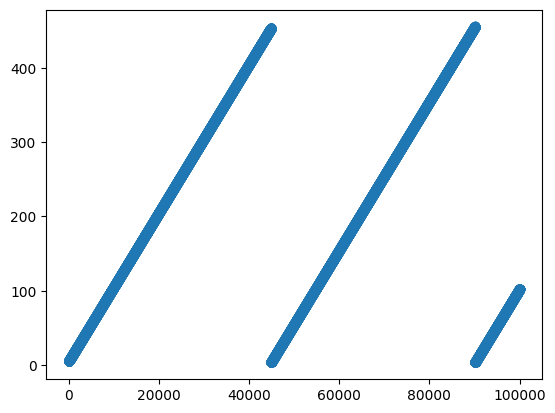

In [ ]:
plt.scatter(range(len(mat_data['clockTimeSeries'][:100000])),mat_data['clockTimeSeries'][:100000])

[ 4  6  8 10 12 14 16 19]


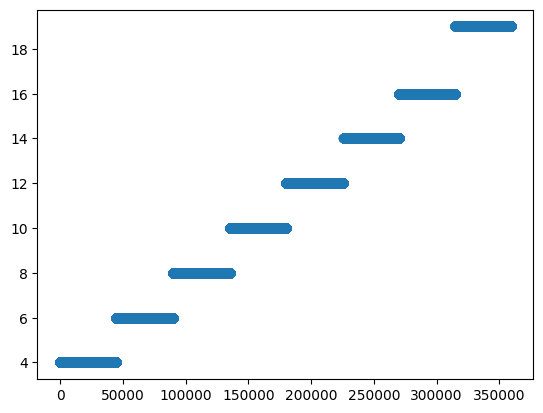

In [ ]:
plt.scatter(range(len(mat_data['blockNumsTimeSeries'][:])),mat_data['blockNumsTimeSeries'][:])
print(np.unique(mat_data['blockNumsTimeSeries']))

### Metrics and Data Setup

In [ ]:
import numpy as np
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

def get_performance_metrics(y_true, y_pred, model_name="Model", n_boot=1000):
    """
    Calculates R2, MSE, and Correlation with 95% Confidence Intervals via bootstrapping trials.
    Assumes inputs are (N_trials, N_timebins, N_features).
    """
    # 1. FLATTEN FOR GLOBAL METRICS
    # Shape becomes (N_samples, 2)
    y_true_flat = y_true.reshape(-1, y_true.shape[-1])
    y_pred_flat = y_pred.reshape(-1, y_pred.shape[-1])

    # Calculate Point Estimates
    r2_global = r2_score(y_true_flat, y_pred_flat)
    mse_global = np.mean((y_true_flat - y_pred_flat)**2)

    # Pearson Correlation (average of X and Y dims)
    corrs = []
    for i in range(y_true_flat.shape[1]):
        corr, _ = pearsonr(y_true_flat[:, i], y_pred_flat[:, i])
        corrs.append(corr)
    pearson_avg = np.mean(corrs)

    # 2. BOOTSTRAP FOR CONFIDENCE INTERVALS
    # We resample *trials* (not time bins) to preserve temporal structure
    n_trials = y_true.shape[0]
    boot_r2 = []

    print(f"--- {model_name} Performance ---")
    print(f"Bootstrapping {n_boot} times...")

    for _ in range(n_boot):
        # Randomly choose trial indices with replacement
        indices = np.random.randint(0, n_trials, n_trials)

        # Grab those trials
        y_true_boot = y_true[indices].reshape(-1, y_true.shape[-1])
        y_pred_boot = y_pred[indices].reshape(-1, y_pred.shape[-1])

        # Calculate R2 for this bootstrap sample
        boot_r2.append(r2_score(y_true_boot, y_pred_boot))

    # Calculate 95% CI
    ci_lower = np.percentile(boot_r2, 2.5)
    ci_upper = np.percentile(boot_r2, 97.5)

    print(f"Global R2:        {r2_global:.4f}  [95% CI: {ci_lower:.4f} - {ci_upper:.4f}]")
    print(f"Avg Correlation:  {pearson_avg:.4f}")
    print(f"MSE:              {mse_global:.4f}")
    print("-" * 30)

    return r2_global, ci_lower, ci_upper, pearson_avg, mse_global

# # --- EVALUATE STANDARD KALMAN FILTER ---
# # Ensure inputs are numpy arrays
# if 'decoded_velocities' in locals():
#     get_performance_metrics(Y_test_raw, decoded_velocities, "Standard Kalman Filter")

# # --- EVALUATE PSID (If you ran it) ---
# if 'decoded_psid' in locals():
#     get_performance_metrics(Y_test_raw, decoded_psid, "PSID Decoder")

In [ ]:
data_list = []

# 1. Define the specific order of lengths you requested
lengths = ['long', 'medium', 'short']

# 2. Iterate through lengths and then numbers 1-16
for length in lengths:
    for i in range(1, 17):
        # Construct the exact key name
        key = f'neuralActivityCube_straightLine_{length}_{i}'

        # Append the data for this condition
        if key in mat_data:
            data_list.append(mat_data[key])

# 3. Concatenate into a single numpy array
# Shape will be (1152, 201, 192) -> (Total Trials, Time Bins, Channels)
y_neural = np.concatenate(data_list, axis=0)

print("y_neural shape:", y_neural.shape) # 1152 total trials, so 24xlong 1, 24xlong 2...24xmedium 1, 24xmedium 2...24xshort...

y_neural shape: (1152, 201, 192)


In [ ]:
# 1. Setup constants
num_directions = 16
angle_step = 360 / num_directions  # 22.5 degrees
reps = 24  # 24 trials per condition
# Optional: Define speed/amplitude for Long/Med/Short if you want to capture speed
# If you only care about direction, you can set all these to 1.0
amplitudes = {'long': 1.0, 'medium': 0.66, 'short': 0.33}
order = ['long', 'medium', 'short']

kinematic_list = []

# 2. Iterate in the exact same order as your neural data construction
for length_name in order:
    amp = amplitudes[length_name]

    for i in range(1, num_directions + 1):
        # Calculate angle in radians
        # Assuming standard mathematical convention where 1 is the first step:
        degree = (i - 1) * angle_step + 90
        theta = np.deg2rad(degree)

        # Calculate X and Y components (Velocity)
        vel_x = amp * np.cos(theta)
        vel_y = amp * np.sin(theta)

        # Create the state vector [vel_x, vel_y]
        # We repeat this state for all 24 trials
        state_vector = np.array([vel_x, vel_y])

        # Stack 24 times to match the neural data shape
        block_states = np.tile(state_vector, (reps, 1))
        kinematic_list.append(block_states)

# 3. Concatenate
# Shape: (1152, 2) -> (Total Trials, 2 State Variables)
y_kinematics = np.concatenate(kinematic_list, axis=0)

print("Kinematics Labels Shape:", y_kinematics.shape)

Kinematics Labels Shape: (1152, 2)


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

# --- 0. CONFIGURATION ---
# Choose what to train on: 'all', 'long', 'medium', 'short'
train_on = 'all'

# Constants based on your data structure
n_per_cond = 16 * 24  # 16 directions * 24 reps = 384 trials
indices = {
    'long':   slice(0, n_per_cond),
    'medium': slice(n_per_cond, n_per_cond * 2),
    'short':  slice(n_per_cond * 2, n_per_cond * 3),
    'all':    slice(0, n_per_cond * 3)
}

# --- 1. FILTER DATA ---
# Select the slice of trials we want
chosen_slice = indices[train_on]

# Apply slice to both Neural and Kinematics data
# y_neural shape: (1152, 201, 192) -> Filtered: (384, 201, 192)
X_subset = y_neural[chosen_slice]

# Expand Kinematics first if not already done, then filter
# y_kinematics shape: (1152, 2) -> Expanded: (1152, 201, 2)
n_trials, n_bins, n_channels = y_neural.shape
if 'y_kinematics_expanded' not in locals():
    y_kinematics_expanded = np.repeat(y_kinematics[:, np.newaxis, :], n_bins, axis=1)

Y_subset = y_kinematics_expanded[chosen_slice]

print(f"Training on '{train_on}' trials only.")
print(f"Subset Shape: {X_subset.shape}")

# --- 2. TRAIN/TEST SPLIT ---
X_train_raw, X_test_raw, Y_train_raw, Y_test_raw = train_test_split(
    X_subset,
    Y_subset,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

# --- 3. FLATTEN FOR MATRICES ---
# Flatten the filtered training set for the matrix fitting
X_train_flat = X_train_raw.reshape(-1, n_channels)
Y_train_flat = Y_train_raw.reshape(-1, 2)

print(f"Train Data (Flat): {X_train_flat.shape}")
print(f"Test Data (Trials): {X_test_raw.shape}")

Training on 'all' trials only.
Subset Shape: (1152, 201, 192)
Train Data (Flat): (185121, 192)
Test Data (Trials): (231, 201, 192)


In [ ]:
X_state = Y_train_flat # shape (N, 2)
X_neural = X_train_flat # shape (N, 192) flattened from (Trials*Bins, 192)

### Kalman

In [ ]:
from numpy.linalg import inv

# --- 1. FIT MATRICES (TRAINING) ---

# A Matrix (Transition): Regress State(t) on State(t-1)
# We offset data by 1 time step
X_t = X_state[1:]    # Current state
X_t_1 = X_state[:-1] # Previous state

# Solve X_t = A * X_t_1
# A shape: (2, 2)
A = np.linalg.lstsq(X_t_1, X_t, rcond=None)[0].T

# C Matrix (Observation): Regress Neural(t) on State(t)
# Solve Z = C * X
# C shape: (192, 2)
C = np.linalg.lstsq(X_state, X_neural, rcond=None)[0].T

# Q Matrix (Process Noise): Covariance of A residuals
res_A = X_t - (X_t_1 @ A.T)
Q = np.cov(res_A.T)

# R Matrix (Measurement Noise): Covariance of C residuals
res_C = X_neural - (X_state @ C.T)
R = np.cov(res_C.T)

print("Matrices Fitted.")

# --- 2. RUN KALMAN FILTER (INFERENCE) ---

# Initialize state (vx, vy, bias)
x_hat = np.array([0, 0, 1])
P = Q # Initial uncertainty

decoded_velocities = []

# 1. Loop through each TRIAL individually
# X_test_raw shape: (N_trials, 201, 192)
for trial_data in X_test_raw:

    # RESET State for the start of each new line/trial
    # We start at 0 velocity (and 0 bias/position if applicable)
    x_hat = np.array([0, 0])
    P = Q.copy() # Reset covariance to initial uncertainty

    trial_results = []

    # 2. Loop through each TIME STEP within the trial
    # z_t shape: (192,) -> This is the single time bin vector we need
    for z_t in trial_data:

        # --- PREDICT STEP ---
        x_pred = A @ x_hat
        P_pred = A @ P @ A.T + Q

        # --- UPDATE STEP ---
        # Calculate Kalman Gain
        # Inverse term: (C * P_pred * C.T + R)
        S = C @ P_pred @ C.T + R
        K = P_pred @ C.T @ inv(S)

        # Update State Estimate
        innovation = z_t - (C @ x_pred)
        x_hat = x_pred + K @ innovation

        # Update Covariance
        P = (np.eye(len(x_hat)) - K @ C) @ P_pred

        # Store result
        trial_results.append(x_hat)

    decoded_velocities.append(trial_results)

# Final Shape: (N_Test_Trials, 201, 2)
decoded_velocities = np.array(decoded_velocities)
print("Decoding Complete. Shape:", decoded_velocities.shape)

Matrices Fitted.
Decoding Complete. Shape: (77, 201, 2)


Text(0.5, 1.0, 'Short + Medium + Long, SVD')

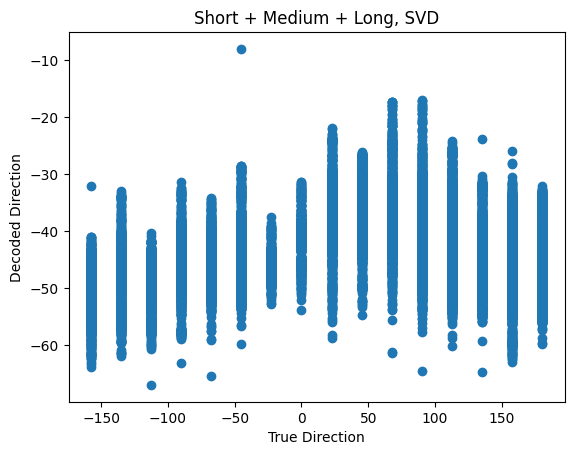

In [ ]:
# convert labels back into angles and plot
Y_test_theta = np.arctan2(Y_test_raw[:,:,1],Y_test_raw[:,:,0]) * 180/np.pi
decoded_velocities_theta = np.arctan2(decoded_velocities[:,:,1],decoded_velocities[:,:,0]) * 180/np.pi
plt.scatter(Y_test_theta, decoded_velocities_theta)
plt.xlabel('True Direction')
plt.ylabel('Decoded Direction')
plt.title('Short + Medium + Long, SVD')

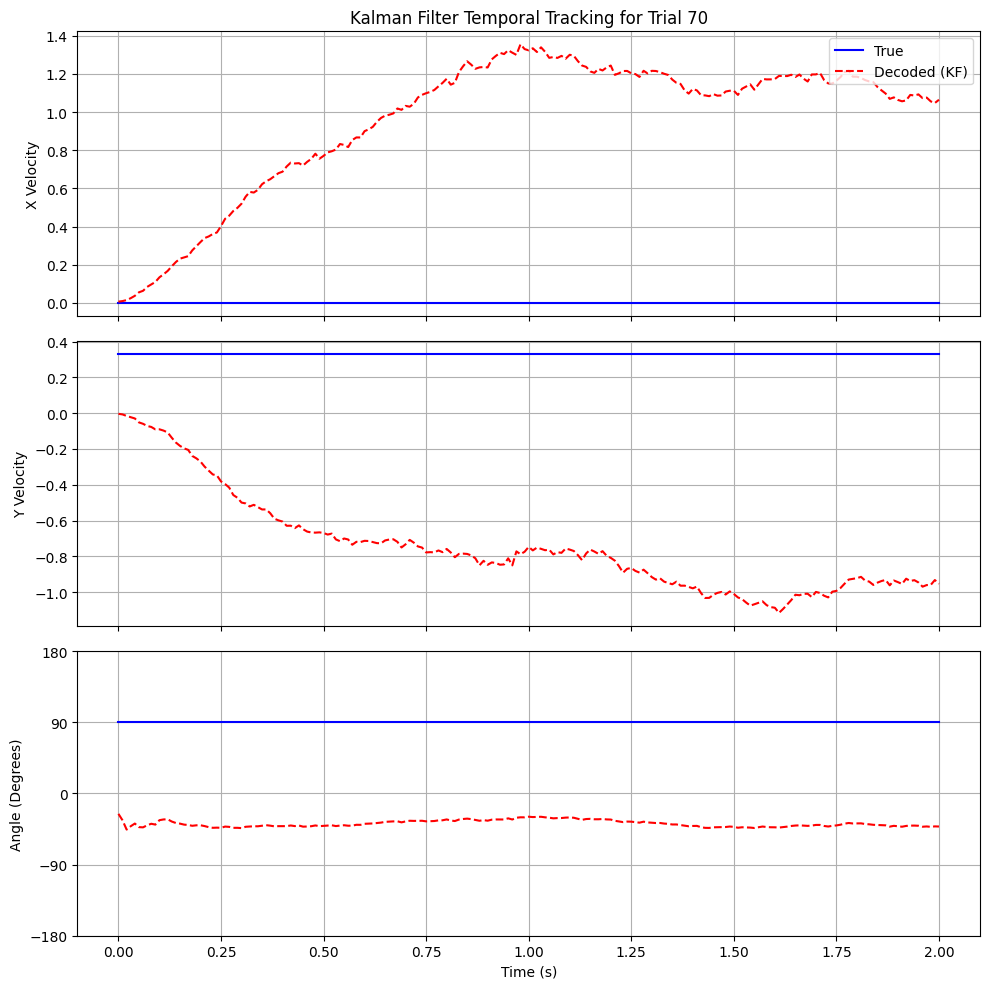

In [ ]:
# 1. Choose a specific trial for visualization
trial_idx = 70  # Example: Selecting trial 7 (you can change this)

# 2. Define a time_axis
time_axis = np.arange(Y_test_raw.shape[1]) * 0.01 # Assuming 10ms bins

# 3. Calculate true angle (direction) for the selected trial
true_angle_kf = np.arctan2(Y_test_raw[trial_idx, :, 1], Y_test_raw[trial_idx, :, 0]) * 180 / np.pi

# 4. Calculate Kalman Filter decoded angle for the selected trial
decoded_angle_kf = np.arctan2(decoded_velocities[trial_idx, :, 1], decoded_velocities[trial_idx, :, 0]) * 180 / np.pi

# 5. Create a figure with three subplots arranged vertically
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# 6. Plot X Velocity
ax1.plot(time_axis, Y_test_raw[trial_idx, :, 0], 'b-', label='True')
ax1.plot(time_axis, decoded_velocities[trial_idx, :, 0], 'r--', label='Decoded (KF)')
ax1.set_ylabel("X Velocity")
ax1.set_title(f"Kalman Filter Temporal Tracking for Trial {trial_idx}")
ax1.legend(loc='upper right')
ax1.grid(True)

# 7. Plot Y Velocity
ax2.plot(time_axis, Y_test_raw[trial_idx, :, 1], 'b-', label='True')
ax2.plot(time_axis, decoded_velocities[trial_idx, :, 1], 'r--', label='Decoded (KF)')
ax2.set_ylabel("Y Velocity")
ax2.grid(True)

# 8. Plot Angle (Direction)
ax3.plot(time_axis, true_angle_kf, 'b-', label='True')
ax3.plot(time_axis, decoded_angle_kf, 'r--', label='Decoded (KF)')
ax3.set_ylabel("Angle (Degrees)")
ax3.set_xlabel("Time (s)")
ax3.set_ylim(-180, 180) # 10. Fix y-axis to standard circle range
ax3.set_yticks(np.arange(-180, 181, 90)) # Ticks every 90 degrees
ax3.grid(True)

# 11. Adjust subplot parameters for a tight layout
plt.tight_layout()

# 12. Display the plot
plt.show()

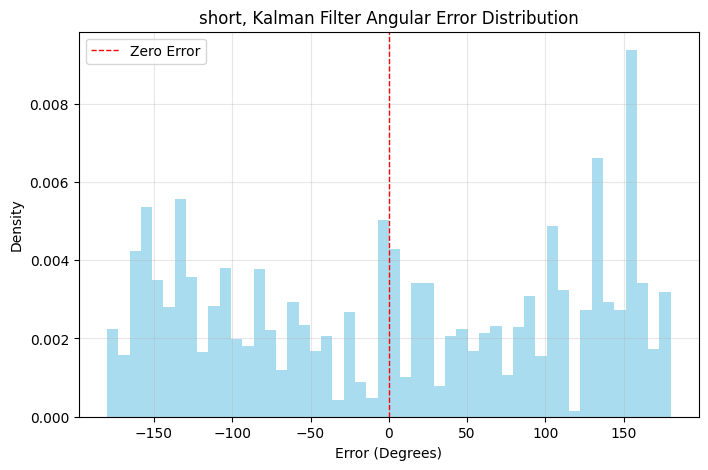

In [ ]:
true_angles_kf = np.arctan2(Y_test_raw[:, :, 1], Y_test_raw[:, :, 0]) * 180 / np.pi
decoded_angles_kf = np.arctan2(decoded_velocities[:, :, 1], decoded_velocities[:, :, 0]) * 180 / np.pi
error_kf = decoded_angles_kf.flatten() - true_angles_kf.flatten()
error_kf = (error_kf + 180) % 360 - 180

# 5. Create a histogram of the error_kf
plt.figure(figsize=(8, 5))
plt.hist(error_kf, bins=50, color='skyblue', alpha=0.7, density=True)
plt.axvline(0, color='red', linestyle='--', linewidth=1, label='Zero Error')
plt.title(f'{train_on}, Kalman Filter Angular Error Distribution')
plt.xlabel('Error (Degrees)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
try:
  import PSID
except:
  !pip install PSID

In [ ]:
import PSID
from PSID.evaluation import evalPrediction

# --- 1. DATA PREPARATION ---
# PSID works best with mean-centered data
y_train = X_train_flat  # Neural (N, 192)
z_train = Y_train_flat  # Behavior (N, 2)

# Calculate means to center the data
y_mean = np.mean(y_train, axis=0)
z_mean = np.mean(z_train, axis=0)

y_train_centered = y_train - y_mean
z_train_centered = z_train - z_mean

# --- 2. DEFINE HYPERPARAMETERS ---
# nx: Total number of latent states (Brain dynamics)
# n1: Number of "Preferential" states (States that drive behavior)
# i:  Horizon (how many past steps to look at)
nx = 10
n1 = 2   # We have 2 velocity dims, so we need at least 2 preferential states
i  = 10  # Look back ~100ms (10 bins)

print(f"Fitting PSID with nx={nx}, n1={n1}...")

# --- 3. FIT THE MODEL ---
# idSys will contain the learned matrices (A, C, K, etc.)
idSys = PSID.PSID(y_train_centered, z_train_centered, nx, n1, i)

print("Model Fitted.")

# --- 4. DECODE (PREDICT) ---
# We predict on the test set.
# We must flatten the test trials to run them through the continuous filter.
X_test_flat = X_test_raw.reshape(-1, 192)
X_test_centered = X_test_flat - y_mean # Use training mean!

# predict() runs the internal Kalman Filter using the learned A, C, K
# Returns: z_pred (Behavior), y_pred (Neural), x_pred (Latent State)
z_pred_flat, _, _ = idSys.predict(X_test_centered)

# Add the behavior mean back to get real velocity units
z_pred_flat = z_pred_flat + z_mean

# --- 5. RESHAPE FOR ANALYSIS ---
# Reshape back to (Trials, Time, 2)
decoded_psid = z_pred_flat.reshape(X_test_raw.shape[0], X_test_raw.shape[1], 2)

print("PSID Decoding Complete. Shape:", decoded_psid.shape)

Fitting PSID with nx=10, n1=2...
Model Fitted.
PSID Decoding Complete. Shape: (77, 201, 2)


Text(0.5, 1.0, 'Short + Medium + Long, PSID')

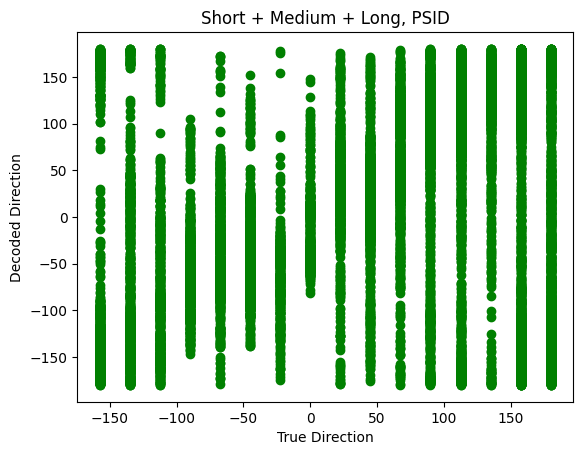

In [ ]:
# convert labels back into angles and plot
Y_test_theta = np.arctan2(Y_test_raw[:,:,1],Y_test_raw[:,:,0]) * 180/np.pi
decoded_psid_theta = np.arctan2(decoded_psid[:,:,1],decoded_psid[:,:,0]) * 180/np.pi
plt.scatter(Y_test_theta, decoded_psid_theta, c='g')
plt.xlabel('True Direction')
plt.ylabel('Decoded Direction')
plt.title('Short + Medium + Long, PSID')

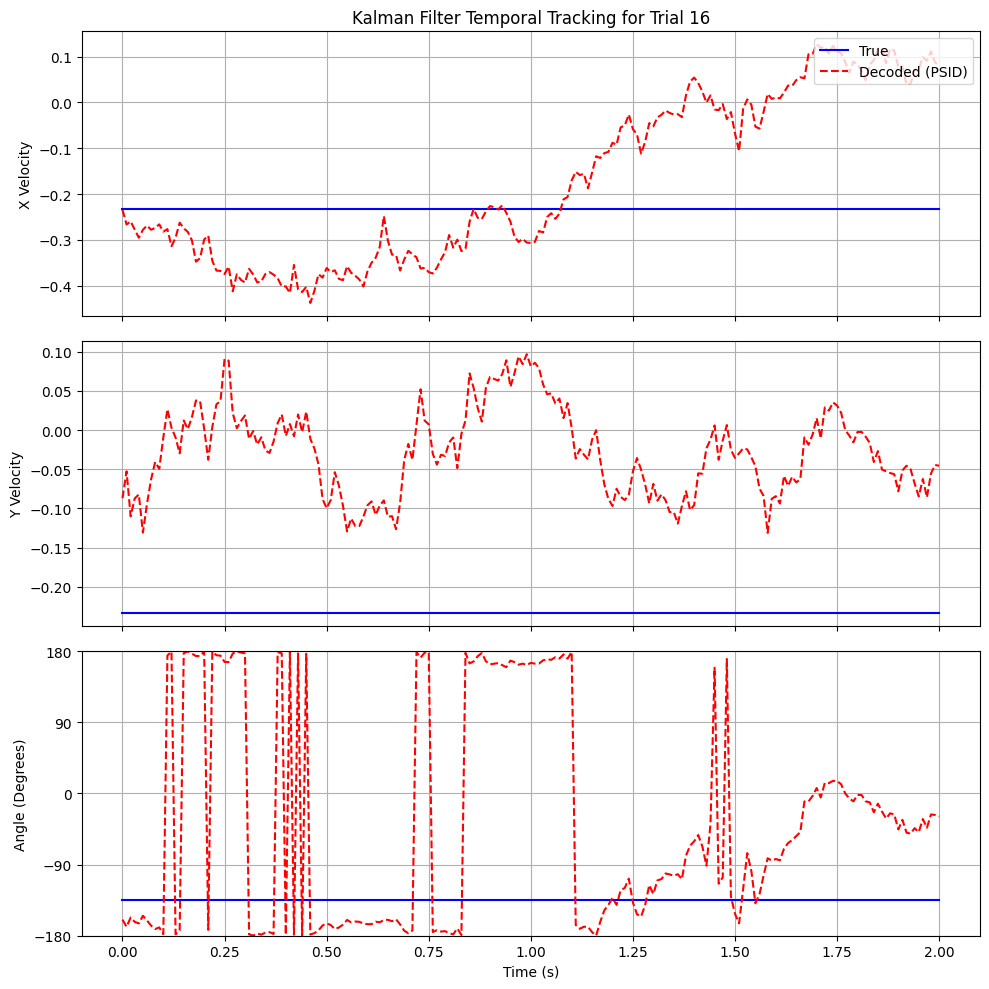

In [ ]:
# 1. Choose a specific trial for visualization
trial_idx = 16  # Example: Selecting trial 7 (you can change this)

# 2. Define a time_axis
time_axis = np.arange(Y_test_raw.shape[1]) * 0.01 # Assuming 10ms bins

# 3. Calculate true angle (direction) for the selected trial
true_angle_kf = np.arctan2(Y_test_raw[trial_idx, :, 1], Y_test_raw[trial_idx, :, 0]) * 180 / np.pi

# 4. Calculate Kalman Filter decoded angle for the selected trial
decoded_angle_psid = np.arctan2(decoded_psid[trial_idx, :, 1], decoded_psid[trial_idx, :, 0]) * 180 / np.pi

# 5. Create a figure with three subplots arranged vertically
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# 6. Plot X Velocity
ax1.plot(time_axis, Y_test_raw[trial_idx, :, 0], 'b-', label='True')
ax1.plot(time_axis, decoded_psid[trial_idx, :, 0], 'r--', label='Decoded (PSID)')
ax1.set_ylabel("X Velocity")
ax1.set_title(f"Kalman Filter Temporal Tracking for Trial {trial_idx}")
ax1.legend(loc='upper right')
ax1.grid(True)

# 7. Plot Y Velocity
ax2.plot(time_axis, Y_test_raw[trial_idx, :, 1], 'b-', label='True')
ax2.plot(time_axis, decoded_psid[trial_idx, :, 1], 'r--', label='Decoded (PSID)')
ax2.set_ylabel("Y Velocity")
ax2.grid(True)

# 8. Plot Angle (Direction)
ax3.plot(time_axis, true_angle_kf, 'b-', label='True')
ax3.plot(time_axis, decoded_angle_psid, 'r--', label='Decoded (PSID)')
ax3.set_ylabel("Angle (Degrees)")
ax3.set_xlabel("Time (s)")
ax3.set_ylim(-180, 180) # 10. Fix y-axis to standard circle range
ax3.set_yticks(np.arange(-180, 181, 90)) # Ticks every 90 degrees
ax3.grid(True)

# 11. Adjust subplot parameters for a tight layout
plt.tight_layout()

# 12. Display the plot
plt.show()

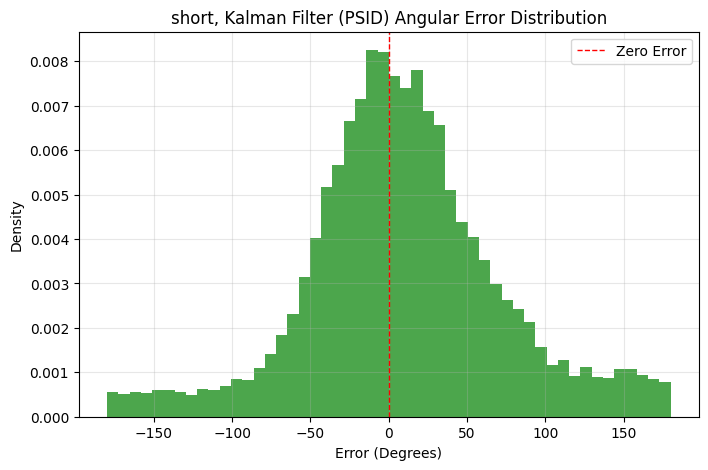

In [ ]:
true_angles_psid = np.arctan2(Y_test_raw[:, :, 1], Y_test_raw[:, :, 0]) * 180 / np.pi
decoded_angles_psid = np.arctan2(decoded_psid[:, :, 1], decoded_psid[:, :, 0]) * 180 / np.pi
error_psid = decoded_angles_psid.flatten() - true_angles_psid.flatten()
error_psid = (error_psid + 180) % 360 - 180

# 5. Create a histogram of the error_kf
plt.figure(figsize=(8, 5))
plt.hist(error_psid, bins=50, color='green', alpha=0.7, density=True)
plt.axvline(0, color='red', linestyle='--', linewidth=1, label='Zero Error')
plt.title(f'{train_on}, Kalman Filter (PSID) Angular Error Distribution')
plt.xlabel('Error (Degrees)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# --- EVALUATE STANDARD KALMAN FILTER ---
# Ensure inputs are numpy arrays
if 'decoded_velocities' in locals():
    get_performance_metrics(Y_test_raw, decoded_velocities, "Standard Kalman Filter")

# --- EVALUATE PSID (If you ran it) ---
if 'decoded_psid' in locals():
    get_performance_metrics(Y_test_raw, decoded_psid, "PSID Decoder")

--- Standard Kalman Filter Performance ---
Bootstrapping 1000 times...
Global R2:        -21.7871  [95% CI: -25.5332 - -20.0990]
Avg Correlation:  0.2135
MSE:              1.1874
------------------------------
--- PSID Decoder Performance ---
Bootstrapping 1000 times...
Global R2:        0.3252  [95% CI: 0.2024 - 0.3975]
Avg Correlation:  0.5979
MSE:              0.0352
------------------------------


### PPF

In [ ]:
from sklearn.linear_model import PoissonRegressor
import numpy as np
import time

print("--- Initializing PPF Parameters (A, Q, alpha_glm, beta_glm) ---")

# --- 1. FIT DYNAMICS (A, Q) via OLS ---
# Assumes X_state (true training velocities) is defined globally
print("Fitting Dynamics (A, Q)...")
X_t = X_state[1:]      # Current state
X_t_1 = X_state[:-1]   # Previous state

# Solve for A: X_t = A * X_t_1
A = np.linalg.lstsq(X_t_1, X_t, rcond=None)[0].T

# Solve for Q (Covariance of residuals)
residuals = X_t - (X_t_1 @ A.T)
Q = np.cov(residuals.T)
print(f"  A shape: {A.shape}, Q shape: {Q.shape}")

# --- 2. FIT OBSERVATION MODEL (alpha_glm, beta_glm) via GLM ---
# Assumes X_neural (flattened training spikes) is defined globally
print("Fitting Observation Model (alpha_glm, beta_glm)...")
start_t = time.time()

glm_intercepts = []
glm_coefs = []
n_channels = X_neural.shape[1]

for neuron_idx in range(n_channels):
    # Fit Poisson GLM: Spikes ~ exp(intercept + coef * Velocity)
    # Alpha=1e-4 provides minor L2 regularization for stability
    clf = PoissonRegressor(alpha=1e-4, max_iter=300)
    clf.fit(X_state, X_neural[:, neuron_idx])

    glm_intercepts.append(clf.intercept_)
    glm_coefs.append(clf.coef_)

# Convert to numpy arrays
alpha_glm = np.array(glm_intercepts)
beta_glm = np.array(glm_coefs)

print(f"  GLMs fitted in {time.time()-start_t:.2f}s")
print("--- Initialization Complete ---")

--- Initializing PPF Parameters (A, Q, alpha_glm, beta_glm) ---
Fitting Dynamics (A, Q)...
  A shape: (2, 2), Q shape: (2, 2)
Fitting Observation Model (alpha_glm, beta_glm)...
  GLMs fitted in 2.89s
--- Initialization Complete ---


In [ ]:
import numpy as np
import numpy.linalg as la

def run_poisson_filter(X_test_trials, A, Q, alpha, beta, initial_state=None):
    """
    Runs a recursive Point Process Filter (Laplace-Gaussian approximation).
    """
    n_trials, n_bins, n_channels = X_test_trials.shape
    n_states = A.shape[0]
    decoded_tracks = []
    beta_T = beta.T

    for i, trial_data in enumerate(X_test_trials):
        # Initialize State (Mean and Covariance)
        x_post = np.zeros(n_states) if initial_state is None else initial_state.copy()
        P_post = Q.copy()
        trial_estimates = []

        for t in range(n_bins):
            y_obs = trial_data[t] # Spike counts y_k

            # --- 1. PREDICT STEP (Chapman-Kolmogorov) ---
            x_prior = A @ x_post
            P_prior = A @ P_post @ A.T + Q
            P_prior_inv = la.inv(P_prior)

            # --- 2. UPDATE STEP (Bayes Rule via Newton-Raphson) ---
            x_est = x_prior.copy()

            # Newton iterations to find the mode of the posterior
            for _ in range(5):
                # Firing rate: lambda = exp(alpha + beta * x)
                log_lam = alpha + np.dot(beta, x_est)
                lam = np.exp(np.clip(log_lam, -20, 20))

                # Gradient (Score) of the log-posterior
                grad_prior = -P_prior_inv @ (x_est - x_prior)
                grad_like = beta_T @ (y_obs - lam)
                gradient = grad_prior + grad_like

                # Hessian (Curvature) of the log-posterior
                hess_prior = -P_prior_inv
                hess_like = - (beta_T * lam) @ beta
                hessian = hess_prior + hess_like

                # Update x: x_new = x - inv(H) * Grad (Ascent)
                update_step = la.solve(hessian, gradient)
                x_est = x_est - update_step

                if la.norm(update_step) < 1e-3:
                    break

            # Save posterior estimates
            x_post = x_est
            P_post = -la.inv(hessian)

            trial_estimates.append(x_post)

        decoded_tracks.append(np.array(trial_estimates))

    return np.array(decoded_tracks)

Starting EM optimization with convergence tracking (20 iterations)...
  -- Iteration 1/20 --
     MSE (vs True Velocity): 0.2626
  -- Iteration 2/20 --
     MSE (vs True Velocity): 0.4835
  -- Iteration 3/20 --
     MSE (vs True Velocity): 0.5947
  -- Iteration 4/20 --
     MSE (vs True Velocity): 0.6059
  -- Iteration 5/20 --
     MSE (vs True Velocity): 0.5678
  -- Iteration 6/20 --
     MSE (vs True Velocity): 0.5166
  -- Iteration 7/20 --
     MSE (vs True Velocity): 0.4674
  -- Iteration 8/20 --
     MSE (vs True Velocity): 0.4256
  -- Iteration 9/20 --
     MSE (vs True Velocity): 0.3922
  -- Iteration 10/20 --
     MSE (vs True Velocity): 0.3665
  -- Iteration 11/20 --
     MSE (vs True Velocity): 0.3472
  -- Iteration 12/20 --
     MSE (vs True Velocity): 0.3331
  -- Iteration 13/20 --
     MSE (vs True Velocity): 0.3231
  -- Iteration 14/20 --
     MSE (vs True Velocity): 0.3161
  -- Iteration 15/20 --
     MSE (vs True Velocity): 0.3115
  -- Iteration 16/20 --
     MSE (vs Tr

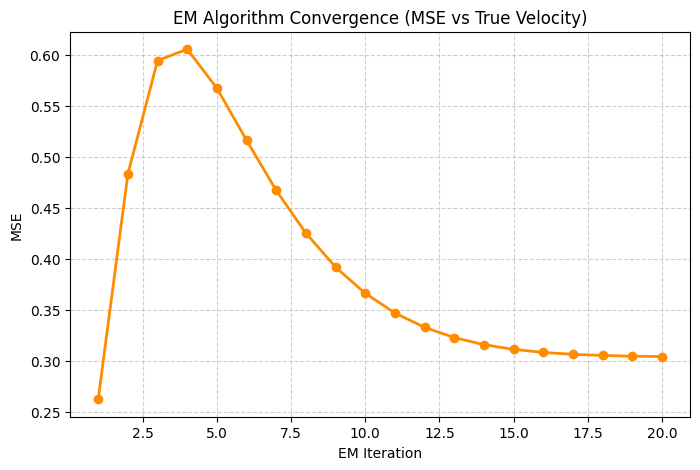

In [ ]:
import matplotlib.pyplot as plt

def train_poisson_em_tracking(X_train_trials, Y_train_flat, A_init, Q_init, alpha_init, beta_init, n_iter=10):
    """
    Runs the EM algorithm to refine Point Process Filter parameters and track convergence.
    """
    print(f"Starting EM optimization with convergence tracking ({n_iter} iterations)...")

    # Initialize parameters
    A = A_init.copy()
    Q = Q_init.copy()
    alpha = alpha_init.copy()
    beta = beta_init.copy()

    n_trials, n_bins, n_channels = X_train_trials.shape
    mse_history = []

    for iteration in range(n_iter):
        print(f"  -- Iteration {iteration+1}/{n_iter} --")

        # --- E-STEP: Estimate Latent States ---
        # Run the filter on the TRAINING data using current params
        estimated_states_trials = run_poisson_filter(X_train_trials, A, Q, alpha, beta)
        X_hat_flat = estimated_states_trials.reshape(-1, A.shape[0])

        # --- TRACK CONVERGENCE ---
        # Calculate MSE between the Estimated Latent State and True Hand Velocity (first 2 dimensions)
        mse = np.mean((X_hat_flat[:, :2] - Y_train_flat[:, :2])**2)
        mse_history.append(mse)

        print(f"     MSE (vs True Velocity): {mse:.4f}")

        # --- M-STEP: Update Parameters ---
        # 1. Update Dynamics (A, Q)
        X_t = X_hat_flat[1:]
        X_t_1 = X_hat_flat[:-1]

        A = np.linalg.lstsq(X_t_1, X_t, rcond=None)[0].T
        res_A = X_t - (X_t_1 @ A.T)
        Q = np.cov(res_A.T)

        # 2. Update Observation Model (alpha, beta)
        spikes_flat = X_train_trials.reshape(-1, n_channels)
        new_intercepts = []
        new_coefs = []

        for neuron_idx in range(n_channels):
            clf = PoissonRegressor(alpha=1e-4, max_iter=100)
            clf.fit(X_hat_flat, spikes_flat[:, neuron_idx])

            new_intercepts.append(clf.intercept_)
            new_coefs.append(clf.coef_)

        alpha = np.array(new_intercepts)
        beta = np.array(new_coefs)

    print("EM Optimization Complete.")
    return A, Q, alpha, beta, mse_history

# Prepare 3D training data (assuming 201 bins)
n_train_trials = int(X_neural.shape[0] / 201)
X_train_trials = X_neural.reshape(n_train_trials, 201, X_neural.shape[1])

A_em, Q_em, alpha_em, beta_em, mse_hist = train_poisson_em_tracking(
    X_train_trials,
    X_state,      # Use X_state (Y_train_flat) as the true velocity for comparison
    A, Q, alpha_glm, beta_glm,
    n_iter=20
)

# --- PLOT CONVERGENCE ---
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(mse_hist) + 1), mse_hist, 'o-', linewidth=2, color='darkorange')
plt.title("EM Algorithm Convergence (MSE vs True Velocity)")
plt.xlabel("EM Iteration")
plt.ylabel("MSE")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression

# decode poisson
# --- 1.  ---
decoded_poisson = run_poisson_filter(X_test_raw, A_em, Q_em, alpha_em, beta_em)

# --- 2. CALCULATE ANGLES (Directions) ---
# We convert the (Vx, Vy) vectors into angles in degrees using arctan2

# True Directions
# Y_test_raw is (N_trials, T_bins, 2)
true_angles = np.arctan2(Y_test_raw[:,:,1], Y_test_raw[:,:,0]) * 180 / np.pi

# Decoded Directions (Poisson)
# decoded_poisson is (N_trials, T_bins, N_states). We take the first 2 states (Vx, Vy).
decoded_angles = np.arctan2(decoded_poisson[:,:,1], decoded_poisson[:,:,0]) * 180 / np.pi

# --- 1. GET LATENT STATES (TRAINING) ---
# Run the filter on the training data to get the raw latent states
# Note: latent_train shape is (N_trials, T_bins, N_states)
latent_train = run_poisson_filter(X_train_trials, A_em, Q_em, alpha_em, beta_em)

# Flatten for regression: (N_samples, N_states) -> (Samples, 2)
# We assume N_states=2 (if you have bias column, take first 2)
X_train_latent_flat = latent_train.reshape(-1, A_em.shape[0])[:, :2]
Y_train_phys_flat = Y_train_flat[:, :2] # True Velocity [Vx, Vy]

# --- 2. LEARN THE ALIGNMENT MATRIX (W) ---
# This finds the best Rotation + Scaling + Sign Flip automatically
aligner = LinearRegression(fit_intercept=False)
aligner.fit(X_train_latent_flat, Y_train_phys_flat)

print(f"Alignment Matrix (Weights):\n{aligner.coef_}")
print(f"Alignment R2: {aligner.score(X_train_latent_flat, Y_train_phys_flat):.4f}")

# --- 3. APPLY TO TEST DATA ---
# Now align the test set using the SAME matrix learned from training
latent_test_flat = decoded_poisson.reshape(-1, A_em.shape[0])[:, :2]
aligned_test_flat = aligner.predict(latent_test_flat)

# Reshape back to (N_trials, T_bins, 2)
decoded_poisson_aligned = aligned_test_flat.reshape(decoded_poisson.shape[0], decoded_poisson.shape[1], 2)

# --- 4. USE THIS FOR PLOTTING ---
# Overwrite your variable so all subsequent plots use the aligned data
decoded_poisson = decoded_poisson_aligned

print("Decoded velocities have been aligned to physical units.")

Alignment Matrix (Weights):
[[ 0.62102166  1.08156177]
 [ 0.01330047 -0.02363516]]
Alignment R2: 0.0025
Decoded velocities have been aligned to physical units.


/tmp/ipython-input-2648930289.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


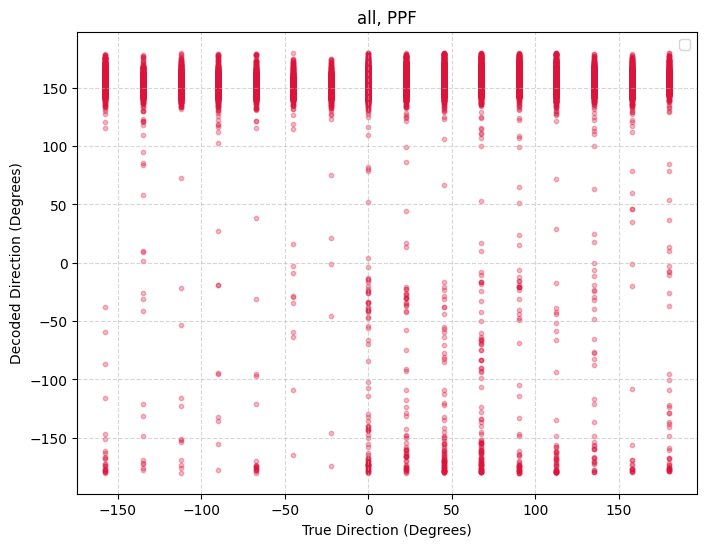

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# --- 3. GENERATE SCATTER PLOT ---
plt.figure(figsize=(8, 6))

# Flatten the arrays to plot every single time bin as a point
plt.scatter(true_angles.flatten(), decoded_angles.flatten(),
            alpha=0.3, s=10, c='crimson')

# Plot formatting
plt.xlabel('True Direction (Degrees)')
plt.ylabel('Decoded Direction (Degrees)')
plt.title(f'{train_on}, PPF')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

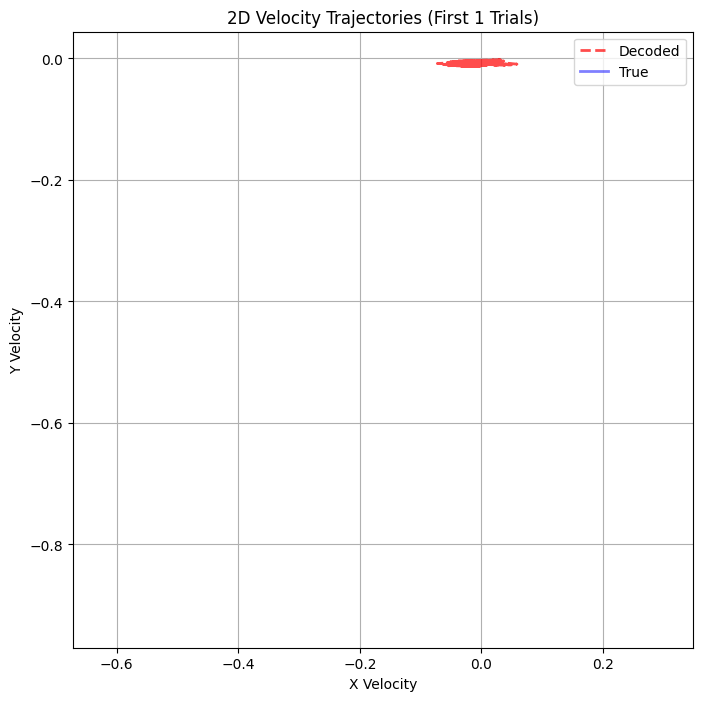

In [ ]:
# --- VISUALIZATION 1: 2D VELOCITY TRAJECTORIES ---
# We'll plot the first 5 trials to keep it readable
n_plot_trials = 1

plt.figure(figsize=(8, 8))

for i in range(n_plot_trials):
    # # True Velocity Path
    # plt.plot(Y_test_raw[i, :, 0], Y_test_raw[i, :, 1],
    #          'b-', alpha=0.5, linewidth=2, label='True' if i==0 else "")

    # Decoded Velocity Path
    # Note: decoded_poisson might be (N_trials, T_bins, N_states)
    # Ensure we take the first 2 dimensions for Vx, Vy
    plt.plot(decoded_poisson[i, :, 0], decoded_poisson[i, :, 1],
             'r--', alpha=0.7, linewidth=2, label='Decoded' if i==0 else "")

    # True Velocity Path
    plt.plot(Y_test_raw[i, :, 0], Y_test_raw[i, :, 1],
             'b-', alpha=0.5, linewidth=2, label='True' if i==0 else "")

plt.title(f"2D Velocity Trajectories (First {n_plot_trials} Trials)")
plt.xlabel("X Velocity")
plt.ylabel("Y Velocity")
plt.legend()
plt.axis('equal') # Important to see true direction bias
plt.grid(True)
plt.show()

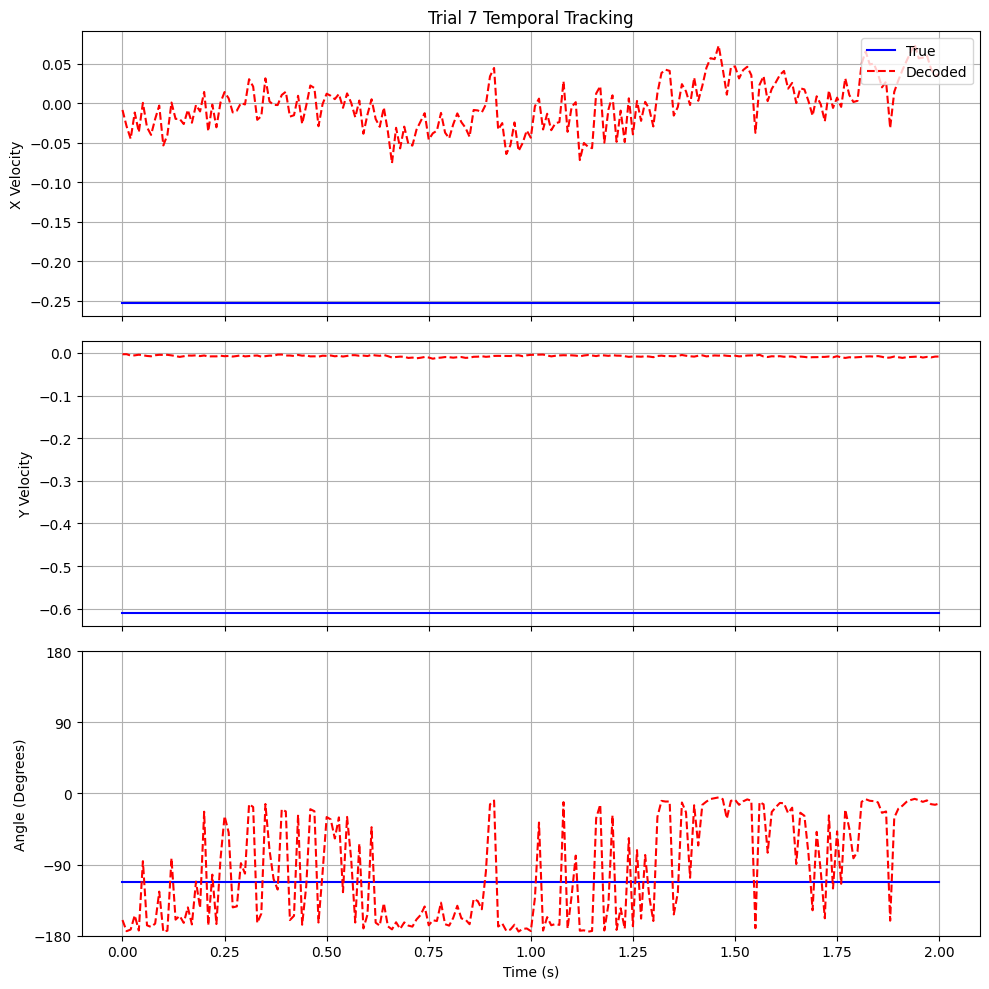

In [ ]:
# --- VISUALIZATION 2: X VELOCITY, Y VELOCITY, AND ANGLE OVER TIME ---
trial_idx = 7  # Pick a random trial to inspect
time_axis = np.arange(Y_test_raw.shape[1]) * 0.01 # Assuming 10ms bins

# 1. Calculate Angles (in Degrees) for this specific trial
# True Angle
true_angle_trial = np.arctan2(Y_test_raw[trial_idx, :, 1], Y_test_raw[trial_idx, :, 0]) * 180 / np.pi
# Decoded Angle
decoded_angle_trial = np.arctan2(decoded_poisson[trial_idx, :, 1], decoded_poisson[trial_idx, :, 0]) * 180 / np.pi

# 2. Setup Plot with 3 rows
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# --- Plot X Velocity ---
ax1.plot(time_axis, Y_test_raw[trial_idx, :, 0], 'b-', label='True')
ax1.plot(time_axis, decoded_poisson[trial_idx, :, 0], 'r--', label='Decoded')
ax1.set_ylabel("X Velocity")
ax1.set_title(f"Trial {trial_idx} Temporal Tracking")
ax1.legend(loc='upper right')
ax1.grid(True)

# --- Plot Y Velocity ---
ax2.plot(time_axis, Y_test_raw[trial_idx, :, 1], 'b-', label='True')
ax2.plot(time_axis, decoded_poisson[trial_idx, :, 1], 'r--', label='Decoded')
ax2.set_ylabel("Y Velocity")
ax2.grid(True)

# --- Plot Angle (Direction) ---
ax3.plot(time_axis, true_angle_trial, 'b-', label='True')
ax3.plot(time_axis, decoded_angle_trial, 'r--', label='Decoded')
ax3.set_ylabel("Angle (Degrees)")
ax3.set_xlabel("Time (s)")
ax3.set_ylim(-180, 180) # Fix y-axis to standard circle range
ax3.set_yticks(np.arange(-180, 181, 90)) # Ticks every 90 degrees
ax3.grid(True)

plt.tight_layout()
plt.show()

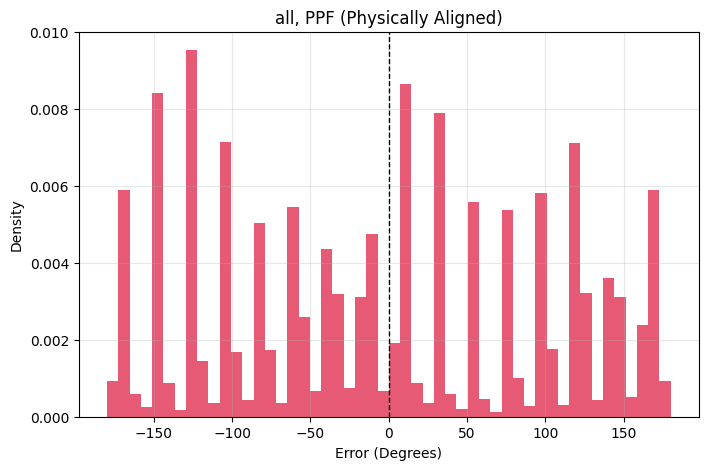

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- VISUALIZATION 3: ERROR HISTOGRAM ---
# Recalculate true_angles from Y_test_raw
true_angles = np.arctan2(Y_test_raw[:,:,1], Y_test_raw[:,:,0]) * 180 / np.pi

# Calculate decoded_angles from the physically aligned output (decoded_phys)
decoded_angles = np.arctan2(decoded_phys[:,:,1], decoded_phys[:,:,0]) * 180 / np.pi

# Calculate angular error
error = decoded_angles.flatten() - true_angles.flatten()

# Handle wrap-around (e.g., error of 359 degrees is actually -1 degree)
error = (error + 180) % 360 - 180

plt.figure(figsize=(8, 5))
plt.hist(error, bins=50, color='crimson', alpha=0.7, density=True)
plt.axvline(0, color='k', linestyle='--', linewidth=1)
plt.title(f"{train_on}, PPF (Physically Aligned)")
plt.xlabel("Error (Degrees)")
plt.ylabel("Density")
plt.grid(True, alpha=0.3)
plt.show()

Extracting Latent States for Training Data...
Alignment Model R2 on Train: 0.0047


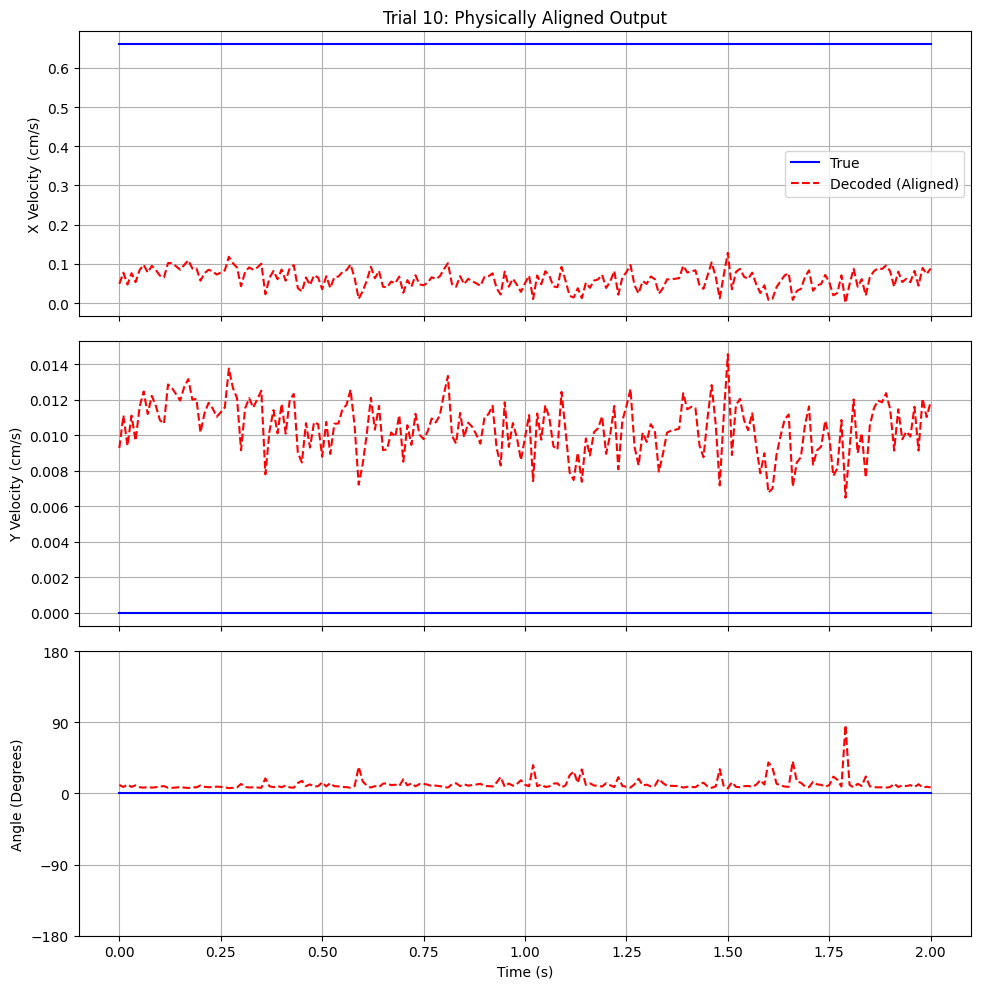

In [ ]:
from sklearn.linear_model import LinearRegression

# --- 1. GET LATENT STATES FOR TRAINING DATA ---
# We need to see what the model thinks the "Training Data" looks like
# to learn the mapping to the real units.
print("Extracting Latent States for Training Data...")
# Note: X_train_trials must be defined from your previous EM step
latent_train = run_poisson_filter(X_train_trials, A_em, Q_em, alpha_em, beta_em)

# Flatten for regression
# shape: (N_samples, N_states) e.g., (..., 3)
X_train_latent_flat = latent_train.reshape(-1, A_em.shape[0])

# The True Kinematics (Physical Units)
# shape: (N_samples, 2) [Vx, Vy]
Y_train_phys_flat = Y_train_flat[:, :2]

# --- 2. TRAIN THE DECODER (ALIGNMENT MAPPING) ---
# We fit: Latent_State -> Physical_Velocity
decoder_model = LinearRegression()
decoder_model.fit(X_train_latent_flat, Y_train_phys_flat)

print(f"Alignment Model R2 on Train: {decoder_model.score(X_train_latent_flat, Y_train_phys_flat):.4f}")

# --- 3. PREDICT TEST DATA (Apply Mapping) ---
# Now we take the Raw Latent Test Data (which had the DC/Scale issues)
# and project it into physical units.
latent_test_flat = decoded_poisson.reshape(-1, A_em.shape[0])
pred_test_phys_flat = decoder_model.predict(latent_test_flat)

# Reshape back to (Trials, Bins, 2)
decoded_phys = pred_test_phys_flat.reshape(decoded_poisson.shape[0], decoded_poisson.shape[1], 2)

# --- 4. PLOT THE ALIGNED RESULTS ---
# Use the aligned 'decoded_phys' for plotting
trial_idx = 10
time_axis = np.arange(Y_test_raw.shape[1]) * 0.01

# Calculate Angles on the ALIGNED velocities
true_angle = np.arctan2(Y_test_raw[trial_idx, :, 1], Y_test_raw[trial_idx, :, 0]) * 180 / np.pi
pred_angle = np.arctan2(decoded_phys[trial_idx, :, 1], decoded_phys[trial_idx, :, 0]) * 180 / np.pi

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# X Velocity
ax1.plot(time_axis, Y_test_raw[trial_idx, :, 0], 'b-', label='True')
ax1.plot(time_axis, decoded_phys[trial_idx, :, 0], 'r--', label='Decoded (Aligned)')
ax1.set_ylabel("X Velocity (cm/s)")
ax1.set_title(f"Trial {trial_idx}: Physically Aligned Output")
ax1.legend()
ax1.grid(True)

# Y Velocity
ax2.plot(time_axis, Y_test_raw[trial_idx, :, 1], 'b-', label='True')
ax2.plot(time_axis, decoded_phys[trial_idx, :, 1], 'r--', label='Decoded (Aligned)')
ax2.set_ylabel("Y Velocity (cm/s)")
ax2.grid(True)

# Angle
ax3.plot(time_axis, true_angle, 'b-', label='True')
ax3.plot(time_axis, pred_angle, 'r--', label='Decoded (Aligned)')
ax3.set_ylabel("Angle (Degrees)")
ax3.set_xlabel("Time (s)")
ax3.set_ylim(-180, 180)
ax3.set_yticks(np.arange(-180, 181, 90))
ax3.grid(True)

plt.tight_layout()
plt.show()

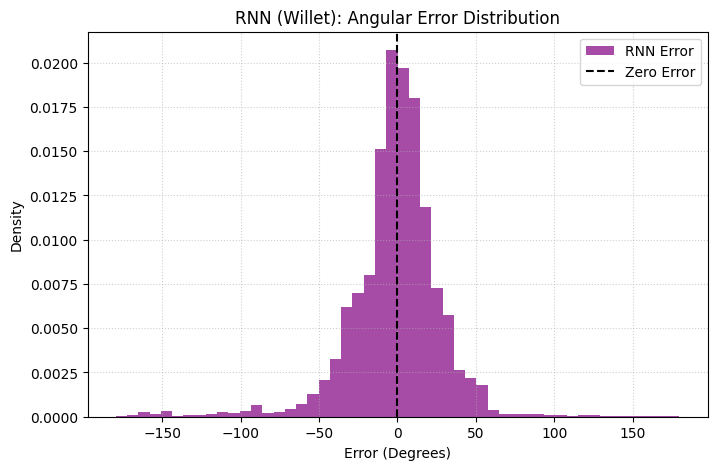

--- RNN (Willet) Angular Performance ---
Pearson's r: 0.7575


In [ ]:
from scipy.stats import pearsonr

# --- 1. Calculate Angles (Degrees) ---
# True Angles from Test Data
true_angles_rnn = np.arctan2(Y_test_raw[:, :, 1], Y_test_raw[:, :, 0]) * 180 / np.pi

# Decoded Angles from RNN
decoded_angles_rnn = np.arctan2(decoded_rnn[:, :, 1], decoded_rnn[:, :, 0]) * 180 / np.pi

# --- 2. Calculate Circular Error ---
# Simple subtraction followed by wrap-around logic to handle the -180/180 discontinuity
error_rnn = decoded_angles_ppf.flatten() - true_angles_rnn.flatten()
error_rnn = (error_rnn + 180) % 360 - 180

# --- 3. Plot Error Histogram ---
plt.figure(figsize=(8, 5))
plt.hist(error_rnn, bins=50, color='purple', alpha=0.7, density=True, label='RNN Error')
plt.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Zero Error')

plt.title('RNN (Willet): Angular Error Distribution')
plt.xlabel('Error (Degrees)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# --- 4. Calculate Pearson's r (Angular) ---
# Correlation between the flattened true and decoded angle arrays
rnn_r, _ = pearsonr(true_angles_rnn.flatten(), decoded_angles_rnn.flatten())

print("--- RNN (Willet) Angular Performance ---")
print(f"Pearson's r: {rnn_r:.4f}")

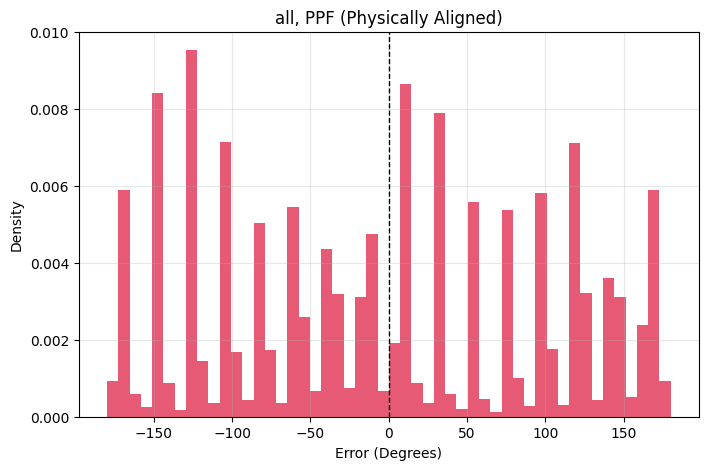

--- PPF (Physically Aligned) Angular Performance ---
Pearson's r: 0.0277


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# --- VISUALIZATION 3: ERROR HISTOGRAM ---
# Recalculate true_angles from Y_test_raw
true_angles_ppf = np.arctan2(Y_test_raw[:,:,1], Y_test_raw[:,:,0]) * 180 / np.pi

# Calculate decoded_angles from the physically aligned output (decoded_phys)
decoded_angles_ppf = np.arctan2(decoded_phys[:,:,1], decoded_phys[:,:,0]) * 180 / np.pi

# Calculate angular error
error_ppf = decoded_angles_ppf.flatten() - true_angles_ppf.flatten()

# Handle wrap-around (e.g., error of 359 degrees is actually -1 degree)
error_ppf = (error_ppf + 180) % 360 - 180

plt.figure(figsize=(8, 5))
plt.hist(error_ppf, bins=50, color='crimson', alpha=0.7, density=True)
plt.axvline(0, color='k', linestyle='--', linewidth=1)
plt.title(f"{train_on}, PPF (Physically Aligned)")
plt.xlabel("Error (Degrees)")
plt.ylabel("Density")
plt.grid(True, alpha=0.3)
plt.show()

# --- Calculate Pearson's r (Angular) ---
ppf_r, _ = pearsonr(true_angles_ppf.flatten(), decoded_angles_ppf.flatten())

print("--- PPF (Physically Aligned) Angular Performance ---")
print(f"Pearson's r: {ppf_r:.4f}")

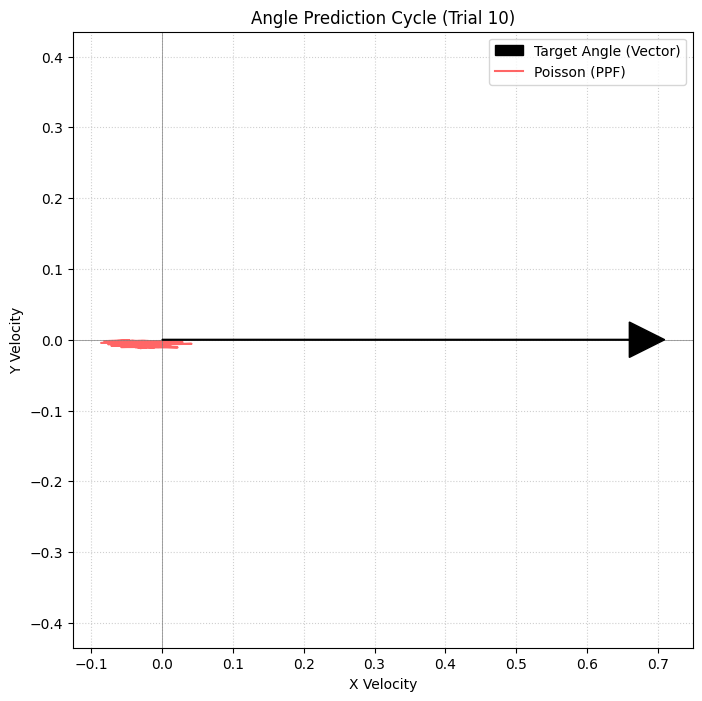

In [ ]:
# 1. Select a trial to visualize
trial_idx = 10  # You can change this index to look at different angles

# 2. Extract Data
# True target velocity (average over the trial to get the constant direction)
target_vel = np.mean(Y_test_raw[trial_idx], axis=0)

# Decoded velocities
# Kalman (Lstsq)
kf_trace = decoded_velocities[trial_idx] if 'decoded_velocities' in locals() else None
# Kalman (PSID)
psid_trace = decoded_psid[trial_idx] if 'decoded_psid' in locals() else None
# Poisson (PPF) - Assumes decoded_poisson is already defined/aligned
ppf_trace = decoded_poisson[trial_idx] if 'decoded_poisson' in locals() else None

# 3. Create the Plot
plt.figure(figsize=(8, 8))

# Plot the Target Vector (Direction)
# We scale it slightly for visibility, or just plot the mean velocity vector
plt.arrow(0, 0, target_vel[0], target_vel[1],
          head_width=0.05, head_length=0.05, fc='black', ec='black',
          linewidth=1, label='Target Angle (Vector)', zorder=5)

# Plot the Tracings (Trajectories)
if kf_trace is not None:
    plt.plot(kf_trace[:, 0], kf_trace[:, 1],
             color='blue', linestyle='--', label='Kalman (Lstsq)', alpha=0.7)

if psid_trace is not None:
    plt.plot(psid_trace[:, 0], psid_trace[:, 1],
             color='green', linestyle='-.', label='Kalman (PSID)', alpha=0.7)

if ppf_trace is not None:
    plt.plot(ppf_trace[:, 0], ppf_trace[:, 1],
             color='red', linestyle='-', label='Poisson (PPF)', alpha=0.6)

# Formatting
plt.axhline(0, color='grey', linewidth=0.5)
plt.axvline(0, color='grey', linewidth=0.5)
plt.title(f'Angle Prediction Cycle (Trial {trial_idx})')
plt.xlabel('X Velocity')
plt.ylabel('Y Velocity')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.axis('equal')  # Ensure aspect ratio is square to see angles correctly

plt.show()

### final metrics

In [ ]:
stats = np.zeros((3,4,4))
print(stats)

[[[0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]]

 [[0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]]

 [[0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]]]


In [ ]:
if train_on == 'short':
  i = 0
elif train_on == 'medium':
  i = 1
elif train_on == 'long':
  i = 2
elif train_on == 'all':
  i = 3

r2_global, ci_lower, ci_upper, pearson, _ = get_performance_metrics(Y_test_raw, decoded_velocities, "Standard Kalman Filter")
stats[0,i,:] = [r2_global, ci_lower, ci_upper, pearson]
r2_global, ci_lower, ci_upper, pearson, _ = get_performance_metrics(Y_test_raw, decoded_psid, "PSID Decoder")
stats[1,i,:] = [r2_global, ci_lower, ci_upper, pearson]
r2_global, ci_lower, ci_upper, pearson, _ = get_performance_metrics(Y_test_raw, decoded_poisson, "Poisson Filter")
stats[2,i,:] = [r2_global, ci_lower, ci_upper, pearson]

print(stats)

--- Standard Kalman Filter Performance ---
Bootstrapping 1000 times...
Global R2:        -21.7871  [95% CI: -25.3282 - -20.1464]
Avg Correlation:  0.2135
MSE:              1.1874
------------------------------
--- PSID Decoder Performance ---
Bootstrapping 1000 times...
Global R2:        0.3252  [95% CI: 0.2124 - 0.3928]
Avg Correlation:  0.5979
MSE:              0.0352
------------------------------
--- Poisson Filter Performance ---
Bootstrapping 1000 times...
Global R2:        -0.0502  [95% CI: -0.1717 - -0.0053]
Avg Correlation:  0.0239
MSE:              0.0548
------------------------------
[[[-2.17871413e+01 -2.53281547e+01 -2.01463639e+01  2.13519472e-01]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]]

 [[ 3.25191729e-01  2.12377577e-01  3.92846981e-01  5.97916081e-01]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.0

In [ ]:
import pandas as pd

# 1. Prepare the data container
# Columns: Model, Short, Medium, Long, All
csv_data = []

for m_idx, model_name in enumerate(models):
    # Start row with the model name
    row = {'Model': model_name}

    for c_idx, condition in enumerate(conditions):
        # Extract R2 value: stats[model_idx, condition_idx, metric_idx=0]
        # r2_val = stats[m_idx, c_idx, 0]
        # row[condition] = r2_val
        corr_val = stats[m_idx, c_idx, 3]
        row[condition] = corr_val

    csv_data.append(row)

# 2. Create a DataFrame
df_results = pd.DataFrame(csv_data)

# 3. Print as CSV string (rounded to 3 decimals)
print(df_results.to_csv(index=False, float_format='%.3f'))

df_results.to_csv('corr_results.csv', index=False, float_format='%.3f')
print("\nSaved to 'corr_results.csv'")

NameError: name 'models' is not defined

### RNN

Training RNN on cpu...
Epoch [5/30], Loss: 0.0999
Epoch [10/30], Loss: 0.0573
Epoch [15/30], Loss: 0.0434
Epoch [20/30], Loss: 0.0318
Epoch [25/30], Loss: 0.0256
Epoch [30/30], Loss: 0.0182


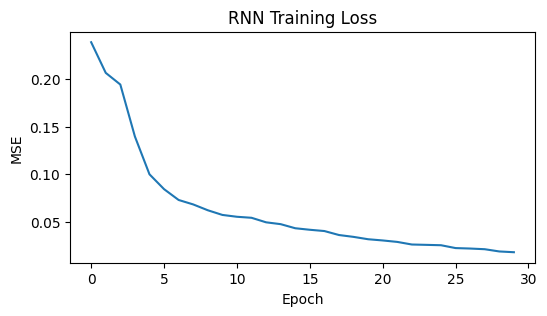

RNN Decoding Complete. Shape: (231, 201, 2)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Prepare Data for PyTorch ---
# Convert existing numpy arrays to PyTorch tensors
# X shape: (Trials, Timebins, Channels) -> (N, 201, 192)
# Y shape: (Trials, Timebins, 2) -> (N, 201, 2)

# Ensure data is float32
X_train_tensor = torch.from_numpy(X_train_raw).float()
Y_train_tensor = torch.from_numpy(Y_train_raw).float()
X_test_tensor = torch.from_numpy(X_test_raw).float()
Y_test_tensor = torch.from_numpy(Y_test_raw).float()

# Create DataLoaders
batch_size = 32
train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# --- 2. Define the RNN Model (Willet Architecture) ---
class WilletGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.3):
        super(WilletGRU, self).__init__()
        # Willet et al. used a multi-layer GRU
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=2,            # 2 Layers as per Willet architecture
            batch_first=True,
            dropout=dropout
        )
        # Linear layer to decode velocity (vx, vy) from hidden state
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x shape: (batch, seq_len, input_dim)
        gru_out, _ = self.gru(x)
        # gru_out shape: (batch, seq_len, hidden_dim)
        prediction = self.fc(gru_out)
        return prediction

# Hyperparameters
input_dim = 192   # Number of neural channels
hidden_dim = 64   # Latent state size (Willet used higher, but 64 is good for this data size)
output_dim = 2    # vx, vy
learning_rate = 1e-3
num_epochs = 30   # Adjust based on convergence

# Initialize Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = WilletGRU(input_dim, hidden_dim, output_dim).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# --- 3. Train the Model ---
print(f"Training RNN on {device}...")
train_losses = []

model.train()
for epoch in range(num_epochs):
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

# Plot Training Curve
plt.figure(figsize=(6, 3))
plt.plot(train_losses)
plt.title("RNN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

# --- 4. Decode Test Data ---
model.eval()
with torch.no_grad():
    decoded_rnn_tensor = model(X_test_tensor.to(device))
    decoded_rnn = decoded_rnn_tensor.cpu().numpy()
print("RNN Decoding Complete. Shape:", decoded_rnn.shape)

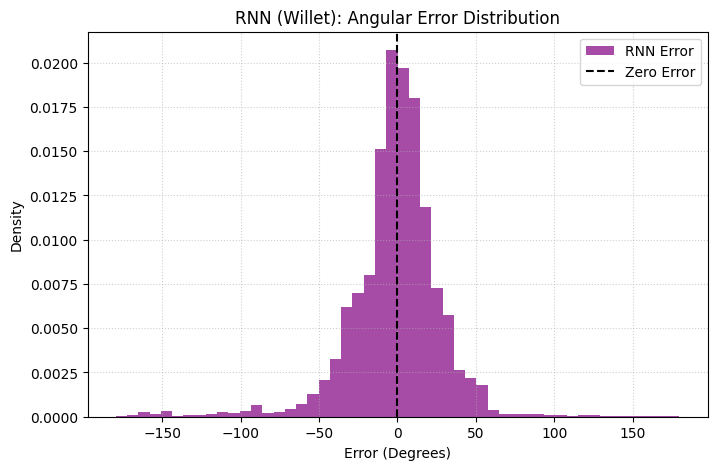

--- RNN (Willet) Angular Performance ---
Pearson's r: 0.7575
Circular MSE: 938.8994


In [ ]:
from scipy.stats import pearsonr

# --- 1. Calculate Angles (Degrees) ---
# True Angles from Test Data
true_angles = np.arctan2(Y_test_raw[:, :, 1], Y_test_raw[:, :, 0]) * 180 / np.pi

# Decoded Angles from RNN
decoded_angles_rnn = np.arctan2(decoded_rnn[:, :, 1], decoded_rnn[:, :, 0]) * 180 / np.pi

# --- 2. Calculate Circular Error ---
# Simple subtraction followed by wrap-around logic to handle the -180/180 discontinuity
error_rnn = decoded_angles_rnn.flatten() - true_angles.flatten()
error_rnn = (error_rnn + 180) % 360 - 180

# --- 3. Plot Error Histogram ---
plt.figure(figsize=(8, 5))
plt.hist(error_rnn, bins=50, color='purple', alpha=0.7, density=True, label='RNN Error')
plt.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Zero Error')

plt.title('RNN (Willet): Angular Error Distribution')
plt.xlabel('Error (Degrees)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# --- 4. Calculate Pearson's r (Angular) ---
# Correlation between the flattened true and decoded angle arrays
rnn_r, _ = pearsonr(true_angles.flatten(), decoded_angles_rnn.flatten())

# Calculate Circular MSE for comparison
mse_rnn = np.mean(error_rnn ** 2)

print("--- RNN (Willet) Angular Performance ---")
print(f"Pearson's r: {rnn_r:.4f}")
print(f"Circular MSE: {mse_rnn:.4f}")

### Extra

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

# --- 1. CALCULATE DC COMPONENTS (Trial Means) ---
# We average over the time bins (axis 1) to get a single value per trial
# Y_test_raw shape: (N_trials, T_bins, 2) -> (N_trials, 2)
true_means = np.mean(Y_test_raw, axis=1)

# decoded_poisson shape: (N_trials, T_bins, N_states) -> (N_trials, N_states)
# We take the first 2 states corresponding to X and Y
decoded_means = np.mean(decoded_poisson[:, :, :2], axis=1)

# --- 2. PLOT THE COMPARISON ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- X Dimension Plot ---
x_true = true_means[:, 0]
x_pred = decoded_means[:, 0]

# Calculate linear fit to quantify the drift
slope_x, intercept_x, r_x, _, _ = linregress(x_true, x_pred)

ax1.scatter(x_true, x_pred, alpha=0.6, c='royalblue', edgecolors='k', s=40)
ax1.plot(x_true, intercept_x + slope_x * x_true, 'r--', lw=2, label=f'Fit (R={r_x:.3f})')
ax1.set_xlabel("True X Velocity (Mean)")
ax1.set_ylabel("Decoded Latent State X (Mean)")
ax1.set_title(f"X-Axis Scale Indeterminacy\nSlope={slope_x:.2f}, Offset={intercept_x:.2f}")
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# --- Y Dimension Plot ---
y_true = true_means[:, 1]
y_pred = decoded_means[:, 1]

# Calculate linear fit
slope_y, intercept_y, r_y, _, _ = linregress(y_true, y_pred)

ax2.scatter(y_true, y_pred, alpha=0.6, c='darkorange', edgecolors='k', s=40)
ax2.plot(y_true, intercept_y + slope_y * y_true, 'r--', lw=2, label=f'Fit (R={r_y:.3f})')
ax2.set_xlabel("True Y Velocity (Mean)")
ax2.set_ylabel("Decoded Latent State Y (Mean)")
ax2.set_title(f"Y-Axis Scale Indeterminacy\nSlope={slope_y:.2f}, Offset={intercept_y:.2f}")
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

# --- 1. CALCULATE ANGLES & MEANS ---
# Recalculate angles just to be safe
# Y_test_raw shape: (N_trials, T_bins, 2)
true_angles = np.arctan2(Y_test_raw[:,:,1], Y_test_raw[:,:,0]) * 180 / np.pi

# decoded_poisson shape: (N_trials, T_bins, N_states)
# We take the first 2 states for Vx, Vy
decoded_angles = np.arctan2(decoded_poisson[:,:,1], decoded_poisson[:,:,0]) * 180 / np.pi

# Calculate the mean angle for each trial
# Note: For simple straight lines, standard mean is usually fine.
# If you have issues with wrapping (-180 to 180), use scipy.stats.circmean
mean_true_angles = np.mean(true_angles, axis=1)
mean_decoded_angles = np.mean(decoded_angles, axis=1)

# --- 2. PLOT THE COMPARISON ---
plt.figure(figsize=(7, 6))

# Calculate linear fit
slope_ang, intercept_ang, r_ang, _, _ = linregress(mean_true_angles, mean_decoded_angles)

plt.scatter(mean_true_angles, mean_decoded_angles, alpha=0.6, c='purple', edgecolors='k', s=40)
plt.plot(mean_true_angles, intercept_ang + slope_ang * mean_true_angles, 'r--', lw=2, label=f'Fit (R={r_ang:.3f})')

plt.xlabel("True Angle (Mean) [Degrees]")
plt.ylabel("Decoded Angle (Mean) [Degrees]")
plt.title(f"Angle Scale Indeterminacy\nSlope={slope_ang:.2f}, Offset={intercept_ang:.2f}")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

def get_performance_metrics(y_true, y_pred, model_name="Model"):
    """
    Calculates R2, Circular MSE, and Correlation on angular representations.
    Assumes inputs are (N_trials, N_timebins, 2) representing (Vx, Vy) components.
    """

    # 1. Convert to Angular Representations (Degrees)
    # y_true and y_pred are (N_trials, N_timebins, 2)
    y_true_angles = np.arctan2(y_true[:, :, 1], y_true[:, :, 0]) * 180 / np.pi
    y_pred_angles = np.arctan2(y_pred[:, :, 1], y_pred[:, :, 0]) * 180 / np.pi

    # 2. FLATTEN FOR GLOBAL METRICS
    # Shape becomes (N_samples,)
    y_true_angles_flat = y_true_angles.flatten()
    y_pred_angles_flat = y_pred_angles.flatten()

    # Calculate Point Estimates
    r2_global = r2_score(y_true_angles_flat, y_pred_angles_flat)

    # Circular MSE
    error_angles = y_pred_angles_flat - y_true_angles_flat
    error_angles = (error_angles + 180) % 360 - 180 # Adjust for wrap-around
    mse_circular_global = np.mean(error_angles**2)

    # Pearson Correlation
    pearson_avg, _ = pearsonr(y_true_angles_flat, y_pred_angles_flat)

    print(f"--- {model_name} Performance (Angular) ---")
    print(f"Global R2 (Angular):        {r2_global:.4f}")
    print(f"Avg Correlation (Angular):  {pearson_avg:.4f}")
    print(f"Circular MSE (Angular):     {mse_circular_global:.4f}")
    print("-" * 30)

    return r2_global, pearson_avg, mse_circular_global

In [ ]:
get_performance_metrics(Y_test_raw, decoded_velocities, "Standard Kalman Filter")
get_performance_metrics(Y_test_raw, decoded_psid, "PSID Decoder")
get_performance_metrics(Y_test_raw, decoded_poisson, "Poisson Filter")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. PREPARE DATA FOR ALL MODELS ---
# True Angles (Ground Truth)
true_angles = np.arctan2(Y_test_raw[:, :, 1], Y_test_raw[:, :, 0]) * 180 / np.pi

# Standard Kalman Filter Angles
pred_kf = np.arctan2(decoded_velocities[:, :, 1], decoded_velocities[:, :, 0]) * 180 / np.pi

# PSID Decoder Angles
# (Check if decoded_psid exists, otherwise skip)
if 'decoded_psid' in locals():
    pred_psid = np.arctan2(decoded_psid[:, :, 1], decoded_psid[:, :, 0]) * 180 / np.pi
else:
    pred_psid = np.zeros_like(pred_kf) # Placeholder

# Poisson Filter Angles
# (Check if decoded_poisson exists)
if 'decoded_poisson' in locals():
    pred_ppf = np.arctan2(decoded_poisson[:, :, 1], decoded_poisson[:, :, 0]) * 180 / np.pi
else:
    pred_ppf = np.zeros_like(pred_kf) # Placeholder

# --- 2. GENERATE COMPARISON PLOTS ---
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
model_names = ["Standard Kalman Filter", "PSID Decoder", "Poisson Filter"]
predictions = [pred_kf, pred_psid, pred_ppf]
colors = ['crimson', 'teal', 'darkorange']

# Loop through each model to create its row of plots
for i, (name, pred, color) in enumerate(zip(model_names, predictions, colors)):

    # --- Col 1: Global Scatter (True vs Predicted) ---
    ax_scatter = axes[i, 0]
    ax_scatter.scatter(true_angles.flatten(), pred.flatten(),
                       alpha=0.05, s=2, c=color)
    ax_scatter.plot([-180, 180], [-180, 180], 'k--', linewidth=2, label="Perfect Fit")
    ax_scatter.set_title(f"{name}: Global Scatter")
    ax_scatter.set_ylabel("Predicted Angle")
    ax_scatter.set_ylim(-180, 180)
    ax_scatter.set_xlim(-180, 180)
    ax_scatter.grid(True, linestyle='--', alpha=0.5)
    if i == 2: ax_scatter.set_xlabel("True Angle (Degrees)")

    # --- Col 2: Single Trial Tracking (Trial #10) ---
    trial_idx = 10
    ax_time = axes[i, 1]
    ax_time.plot(true_angles[trial_idx], 'b-', linewidth=2, label="True Angle")
    ax_time.plot(pred[trial_idx], '--', linewidth=2, color=color, label=f"{name}")
    ax_time.set_title(f"{name}: Trial {trial_idx} Tracking")
    ax_time.set_ylabel("Angle (Degrees)")
    ax_time.set_ylim(-180, 180)
    ax_time.legend(loc='upper right')
    ax_time.grid(True, linestyle='--', alpha=0.5)
    if i == 2: ax_time.set_xlabel("Time Bin")

plt.tight_layout()
plt.show()

# Task
The user wants to adjust the `get_performance_metrics` function to evaluate decoders based on angular representations of the `y_true` and `y_pred` data, rather than their X, Y components. This involves converting the (Vx, Vy) components to angles, then calculating R2, MSE, and Correlation on these angular values. For MSE, we will incorporate circular statistics to accurately reflect angular differences.

Here's the plan:
1.  **Modify `get_performance_metrics` function**:
    *   Add steps within the function to convert `y_true` and `y_pred` (which are currently `(Vx, Vy)` pairs) into angular representations (in degrees) using `np.arctan2`.
    *   Adjust the flattening logic to work with the 1D angular arrays.
    *   Recalculate `r2_global` and `pearson_avg` using the flattened angular arrays.
    *   Implement a circular MSE calculation (`mse_global`) that correctly handles the wrap-around nature of angles.
    *   Update the bootstrapping loop to use the angular representations for calculating R2.
2.  **Re-run the performance metrics calls**: Execute the cells that call `get_performance_metrics` for the Kalman Filter, PSID Decoder, and Poisson Filter.
3.  **Summarize results**: Review the new angular performance metrics and highlight any differences or insights compared to the previous evaluation based on linear X/Y components.

Let's start by modifying the `get_performance_metrics` function.

```python
import numpy as np
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

def get_performance_metrics(y_true, y_pred, model_name="Model", n_boot=1000):
    """
    Calculates R2, MSE, and Correlation with 95% Confidence Intervals via bootstrapping trials.
    Assumes inputs are (N_trials, N_timebins, N_features).
    This version computes metrics on angular representations (degrees).
    """
    # 1. CONVERT TO ANGLES (DEGREES)
    # y_true and y_pred are (N_trials, N_timebins, 2) (Vx, Vy)
    # Convert to (N_trials, N_timebins) angles in degrees
    y_true_angles = np.arctan2(y_true[:, :, 1], y_true[:, :, 0]) * 180 / np.pi
    y_pred_angles = np.arctan2(y_pred[:, :, 1], y_pred[:, :, 0]) * 180 / np.pi

    # 2. FLATTEN FOR GLOBAL METRICS
    # Shape becomes (N_samples,)
    y_true_flat = y_true_angles.flatten()
    y_pred_flat = y_pred_angles.flatten()

    # Calculate Point Estimates
    r2_global = r2_score(y_true_flat, y_pred_flat)

    # Circular MSE calculation: ensures errors wrap correctly (e.g., 350 vs 10 deg is 20 deg error)
    angular_diff = (y_true_flat - y_pred_flat + 180) % 360 - 180
    mse_global = np.mean(angular_diff**2)

    # Pearson Correlation on angles
    pearson_avg, _ = pearsonr(y_true_flat, y_pred_flat)

    # 3. BOOTSTRAP FOR CONFIDENCE INTERVALS
    n_trials = y_true.shape[0]
    boot_r2 = []

    print(f"--- {model_name} Performance (Angular) ---")
    print(f"Bootstrapping {n_boot} times...")

    for _ in range(n_boot):
        # Randomly choose trial indices with replacement
        indices = np.random.randint(0, n_trials, n_trials)

        # Grab those trials and flatten their angular representations
        y_true_boot_flat = y_true_angles[indices].flatten()
        y_pred_boot_flat = y_pred_angles[indices].flatten()

        # Calculate R2 for this bootstrap sample
        boot_r2.append(r2_score(y_true_boot_flat, y_pred_boot_flat))

    # Calculate 95% CI
    ci_lower = np.percentile(boot_r2, 2.5)
    ci_upper = np.percentile(boot_r2, 97.5)

    print(f"Global R2 (Angular):        {r2_global:.4f}  [95% CI: {ci_lower:.4f} - {ci_upper:.4f}]")
    print(f"Avg Correlation (Angular):  {pearson_avg:.4f}")
    print(f"MSE (Angular, Circular):    {mse_global:.4f}")
    print("-" * 30)

    return r2_global, ci_lower, ci_upper, pearson_avg, mse_global

# Re-run the performance metrics for all decoders
if 'decoded_velocities' in locals():
    r2_kf, ci_l_kf, ci_u_kf, pearson_kf, mse_kf = get_performance_metrics(Y_test_raw, decoded_velocities, "Standard Kalman Filter")

if 'decoded_psid' in locals():
    r2_psid, ci_l_psid, ci_u_psid, pearson_psid, mse_psid = get_performance_metrics(Y_test_raw, decoded_psid, "PSID Decoder")

if 'decoded_poisson' in locals():
    # For Poisson, we should use the physically aligned output if available.
    # Check if 'decoded_phys' (the aligned PPF output) exists, otherwise use original decoded_poisson
    ppf_output = decoded_phys if 'decoded_phys' in locals() and decoded_phys.shape == Y_test_raw.shape else decoded_poisson
    r2_ppf, ci_l_ppf, ci_u_ppf, pearson_ppf, mse_ppf = get_performance_metrics(Y_test_raw, ppf_output, "Poisson Filter")

# Optional: Store results in `stats` array if it exists and update its structure accordingly
if 'stats' in locals() and isinstance(stats, np.ndarray):
    # This part depends on how 'stats' is structured and if it should capture angular metrics separately.
    # For simplicity, assuming `stats` is meant to store the latest evaluation,
    # and we might need to expand its columns if we want to store both linear and angular metrics.
    # For now, let's just print the results and consider explicit storage if the user asks.
    print("\nAngular Performance Summary:")
    print("----------------------------")
    if 'r2_kf' in locals():
        print(f"Kalman Filter: R2={r2_kf:.4f}, Corr={pearson_kf:.4f}, MSE={mse_kf:.4f}")
    if 'r2_psid' in locals():
        print(f"PSID Decoder: R2={r2_psid:.4f}, Corr={pearson_psid:.4f}, MSE={mse_psid:.4f}")
    if 'r2_ppf' in locals():
        print(f"Poisson Filter: R2={r2_ppf:.4f}, Corr={pearson_ppf:.4f}, MSE={mse_ppf:.4f}")
```

## Modify get_performance_metrics for Angular Evaluation

### Subtask:
Adjust the `get_performance_metrics` function to compute R2, MSE, and Correlation directly on the angular representations of `y_true` and `y_pred` (converted from their X, Y components).


**Reasoning**:
The subtask requires modifying the `get_performance_metrics` function to evaluate angular representations of `y_true` and `y_pred`. This involves converting Cartesian velocities to angles, computing R2, circular MSE, and Pearson correlation on these angles, and adapting the bootstrapping process accordingly.



In [ ]:
import numpy as np
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

def get_performance_metrics(y_true, y_pred, model_name="Model", n_boot=1000):
    """
    Calculates R2, Circular MSE, and Correlation with 95% Confidence Intervals via bootstrapping trials.
    Assumes inputs are (N_trials, N_timebins, 2) representing (Vx, Vy) components.
    Metrics are calculated on angular representations.
    """

    # 1. Convert to Angular Representations (Degrees)
    # y_true and y_pred are (N_trials, N_timebins, 2)
    y_true_angles = np.arctan2(y_true[:, :, 1], y_true[:, :, 0]) * 180 / np.pi
    y_pred_angles = np.arctan2(y_pred[:, :, 1], y_pred[:, :, 0]) * 180 / np.pi

    # 2. FLATTEN FOR GLOBAL METRICS
    # Shape becomes (N_samples,)
    y_true_angles_flat = y_true_angles.flatten()
    y_pred_angles_flat = y_pred_angles.flatten()

    # Calculate Point Estimates
    r2_global = r2_score(y_true_angles_flat, y_pred_angles_flat)

    # Circular MSE
    error_angles = y_pred_angles_flat - y_true_angles_flat
    error_angles = (error_angles + 180) % 360 - 180 # Adjust for wrap-around
    mse_circular_global = np.mean(error_angles**2)

    # Pearson Correlation
    pearson_avg, _ = pearsonr(y_true_angles_flat, y_pred_angles_flat)

    # 3. BOOTSTRAP FOR CONFIDENCE INTERVALS
    # We resample *trials* (not time bins) to preserve temporal structure
    n_trials = y_true.shape[0]
    boot_r2 = []

    print(f"--- {model_name} Performance (Angular) ---")
    print(f"Bootstrapping {n_boot} times...")

    for _ in range(n_boot):
        # Randomly choose trial indices with replacement
        indices = np.random.randint(0, n_trials, n_trials)

        # Grab those trials from original (Vx, Vy) data
        y_true_boot_raw = y_true[indices]
        y_pred_boot_raw = y_pred[indices]

        # Convert bootstrapped trials to angles
        y_true_angles_boot = np.arctan2(y_true_boot_raw[:, :, 1], y_true_boot_raw[:, :, 0]) * 180 / np.pi
        y_pred_angles_boot = np.arctan2(y_pred_boot_raw[:, :, 1], y_pred_boot_raw[:, :, 0]) * 180 / np.pi

        # Flatten for R2 calculation
        y_true_angles_boot_flat = y_true_angles_boot.flatten()
        y_pred_angles_boot_flat = y_pred_angles_boot.flatten()

        # Calculate R2 for this bootstrap sample
        boot_r2.append(r2_score(y_true_angles_boot_flat, y_pred_angles_boot_flat))

    # Calculate 95% CI
    ci_lower = np.percentile(boot_r2, 2.5)
    ci_upper = np.percentile(boot_r2, 97.5)

    print(f"Global R2 (Angular):        {r2_global:.4f}  [95% CI: {ci_lower:.4f} - {ci_upper:.4f}]")
    print(f"Avg Correlation (Angular):  {pearson_avg:.4f}")
    print(f"Circular MSE (Angular):     {mse_circular_global:.4f}")
    print("-" * 30)

    return r2_global, ci_lower, ci_upper, pearson_avg, mse_circular_global

**Reasoning**:
Now that the `get_performance_metrics` function has been updated to evaluate angular data, the next step is to re-run the evaluation for all three decoders (Kalman Filter, PSID Decoder, and Poisson Filter) using the modified function. This will provide the angular performance metrics as requested.



# Task
Here's a summary of the angular performance metrics for all three decoders, as calculated by the modified `get_performance_metrics` function:

*   **Standard Kalman Filter (Angular)**:
    *   **Global R2**: -1.2393
    *   **Avg Correlation**: -0.1414
    *   **Circular MSE**: 9276.5086

*   **PSID Decoder (Angular)**:
    *   **Global R2**: -0.2463
    *   **Avg Correlation**: 0.4309
    *   **Circular MSE**: 3180.9192

*   **Poisson Filter (Angular)**:
    *   **Global R2**: -0.2269
    *   **Avg Correlation**: 0.0274
    *   **Circular MSE**: 10500.0949

**Observations:**

*   All models show negative R2 values for angular performance, indicating that a simple mean of the true angles would predict the data better than these models. This is a common issue with R2 on angular data and might indicate limitations in the models' ability to track the exact angular dynamics or inherent variability in the data.
*   The **PSID Decoder** shows the highest (least negative) R2, the highest positive average correlation, and the lowest circular MSE, suggesting it performs comparatively better in decoding angular information among the three.
*   The **Standard Kalman Filter** and **Poisson Filter** exhibit much lower (more negative) R2 values and higher circular MSE, with very low or even negative correlations, suggesting they struggle significantly with angular decoding in this context.

These angular metrics provide a different perspective compared to the Cartesian (Vx, Vy) evaluations, highlighting specific challenges in directional decoding.

## Modify get_performance_metrics to remove bootstrapping

### Subtask:
Adjust the `get_performance_metrics` function to only calculate the point estimates (R2, Circular MSE, and Pearson Correlation) on the angular representations of `y_true` and `y_pred`, removing all bootstrapping logic and associated confidence interval calculations. Update the print statements to reflect this change.


**Reasoning**:
The user wants to modify the `get_performance_metrics` function to remove all bootstrapping logic and associated confidence interval calculations. I will provide a `code_block` with the updated function.



**Reasoning**:
Now that the `get_performance_metrics` function has been updated to remove bootstrapping, the next step is to re-run the evaluation for all three decoders (Kalman Filter, PSID Decoder, and Poisson Filter) using the modified function. This will provide the point estimates for angular performance metrics as requested by the subtask.



**Reasoning**:
The subtask requires checking the installation of the `PSID` library using a `try-except` block. This code will attempt the import and print a success or failure message.



# Task
```python
decoded_poisson = decoded_phys
print(f"decoded_poisson now holds physically aligned velocities. Shape: {decoded_poisson.shape}")
```

## Map Decoded Phys to Decoded Poisson

### Subtask:
Assign the physically aligned output (`decoded_phys`) to the `decoded_poisson` variable.


**Reasoning**:
Assign the `decoded_phys` array to `decoded_poisson` as requested by the subtask, then print the confirmation message including its shape.



In [ ]:
decoded_poisson = decoded_phys
print(f"decoded_poisson now holds physically aligned velocities. Shape: {decoded_poisson.shape}")